# 🏠 Use Case : Comment passer de 4 étoiles à 5 étoiles sur Airbnb ?

**Objectif** : Identifier les facteurs qui différencient un logement noté < 4.5 ⭐ d'un logement noté 4.8–5.0 ⭐, et construire un outil de recommandation qui indique à un hôte ce qu'il peut améliorer dans son logement.

---

## Plan d'analyse

1. **Chargement & état des données** — comprendre ce qu'on a
2. **Distribution des notes** — visualiser les segments de rating
3. **Analyse des équipements (Amenities)** — quels équipements ont les logements 5★ que les 4★ n'ont pas ?
4. **Analyse des sous-scores** — cleanliness, accuracy, checkin, communication, location, value
5. **Profil de l'hôte** — superhost, taux de réponse, etc.
6. **Caractéristiques du logement** — bedrooms, taille, prix
7. **NLP sur les descriptions** — mots-clés présents dans les annonces bien notées
8. **IA NLP sur les avis voyageurs** — détection des plaintes (FR + EN) sur 469 309 avis réels
9. **Modèle ML** — prédire le segment de rating + importance des features
10. **Recommandations** — gap analysis par amenity + recommandeur enrichi 3 niveaux
11. **Synthèse & prochaines étapes**
12. **Présentation client** — génération PPTX 6 slides

---

**Données disponibles** :
- `listings.csv` → 12 252 annonces, 79 colonnes (source principale)
- `reviews.csv` → 469 309 avis voyageurs, utilisés pour l'analyse NLP des plaintes (section 8b)


## 1. Setup & Chargement des données

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import re
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Palette cohérente
COLORS = {
    'low':   '#e74c3c',   # rouge  — < 4.5
    'mid':   '#f39c12',   # orange — 4.5–4.79
    'high':  '#2ecc71',   # vert   — 4.8+
    'base':  '#3498db',
}
SEG_COLORS = [COLORS['low'], COLORS['mid'], COLORS['high']]

DATA_PATH = Path('../data_airbnb_bordeaux/listings.csv')
print(f'Chargement depuis : {DATA_PATH.resolve()}')

Chargement depuis : C:\Users\benoi\Desktop\YNOV\semaine_26_05_2026\module_data\airbnb\data_airbnb_bordeaux\listings.csv


In [50]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape brut : {df_raw.shape}')
df_raw.head(2)

Shape brut : (12252, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,222887,https://www.airbnb.com/rooms/222887,20250918041729,2025-09-18,city scrape,"Spectacular view, full air-con, elevator",Imagine yourself relaxing on a 12m² private te...,✔ NEARBY MARKETS – Located near St Michel anti...,https://a0.muscache.com/pictures/8f2b210e-3c0e...,1156398,https://www.airbnb.com/users/show/1156398,Suzanne,2011-09-14,"Duras, France","Originally from New Zealand, I now divide my t...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Hôtel de Ville - Quinconces,24.00,31.00,"['email', 'phone', 'work_email']",...,296,2025-09-18,133,28,2,61,28,168,40488.00,2012-01-04,2025-09-04,4.83,4.84,4.74,4.89,4.95,4.76,4.70,3306300031048,t,4,4,0,0,0.80
1,317273,https://www.airbnb.com/rooms/317273,20250918041729,2025-09-18,city scrape,"Luxury, spacious, patio, near public gardens",Bordeaux City Gardens is a luxurious one-bedro...,✔ PRIME LOCATION – Situated near the Bordeaux ...,https://a0.muscache.com/pictures/miso/Hosting-...,1156398,https://www.airbnb.com/users/show/1156398,Suzanne,2011-09-14,"Duras, France","Originally from New Zealand, I now divide my t...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Hôtel de Ville - Quinconces,24.00,31.00,"['email', 'phone', 'work_email']",...,299,2025-09-18,87,19,3,43,19,114,24396.00,2014-08-13,2025-09-03,4.91,4.98,4.82,4.97,4.95,4.97,4.78,33063001366CB,t,4,4,0,0,0.64


## 2. État des données — colonnes utiles & valeurs manquantes

In [51]:
# Colonnes utiles pour cet use case
REVIEW_COLS = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
HOST_COLS = [
    'host_is_superhost', 'host_response_time', 'host_response_rate',
    'host_acceptance_rate', 'host_identity_verified', 'host_listings_count'
]
PROPERTY_COLS = [
    'property_type', 'room_type', 'accommodates',
    'bedrooms', 'beds', 'bathrooms', 'price'
]
TEXT_COLS = ['name', 'description', 'neighborhood_overview']
USEFUL_COLS = ['id'] + REVIEW_COLS + HOST_COLS + PROPERTY_COLS + TEXT_COLS + ['amenities', 'number_of_reviews', 'neighbourhood_cleansed']

df = df_raw[USEFUL_COLS].copy()
print(f'Shape (colonnes utiles) : {df.shape}')
print()

# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)

Shape (colonnes utiles) : (12252, 27)



,missing,pct
neighborhood_overview,6395,52.20
price,4474,36.50
beds,4461,36.40
bathrooms,4440,36.20
host_response_time,4409,36.00
host_response_rate,4409,36.00
host_acceptance_rate,3715,30.30
review_scores_value,1922,15.70
review_scores_location,1922,15.70
review_scores_accuracy,1920,15.70


In [52]:
# Nettoyage de base
# Prix : retirer $ et convertir en float
df['price_num'] = df['price'].str.replace('[$,]', '', regex=True).astype(float)

# Hôte : convertir les booléens t/f
for col in ['host_is_superhost', 'host_identity_verified']:
    df[col] = df[col].map({'t': True, 'f': False})

# Taux en % → float (0-1)
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].str.replace('%', '', regex=False).astype(float) / 100

# host_response_time → ordinal
response_order = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1
}
df['host_response_time_ord'] = df['host_response_time'].map(response_order)

# Garder uniquement les listings avec une note
df_rated = df[df['review_scores_rating'].notna() & (df['number_of_reviews'] >= 3)].copy()
print(f'Listings avec note (≥ 3 avis) : {len(df_rated)} / {len(df)}')

Listings avec note (≥ 3 avis) : 8899 / 12252


## 3. Distribution des notes & segmentation

In [53]:
# Segmentation en 3 classes
def segment_rating(r):
    if r < 4.5:
        return 'Faible (< 4.5)'
    elif r < 4.8:
        return 'Bon (4.5–4.79)'
    else:
        return 'Excellent (4.8+)'

df_rated['rating_segment'] = df_rated['review_scores_rating'].apply(segment_rating)
seg_order = ['Faible (< 4.5)', 'Bon (4.5–4.79)', 'Excellent (4.8+)']

counts = df_rated['rating_segment'].value_counts()[seg_order]
print(counts)
print(f"\n% Excellent : {counts['Excellent (4.8+)'] / counts.sum() * 100:.1f}%")

rating_segment
Faible (< 4.5)       781
Bon (4.5–4.79)      2713
Excellent (4.8+)    5405
Name: count, dtype: int64

% Excellent : 60.7%


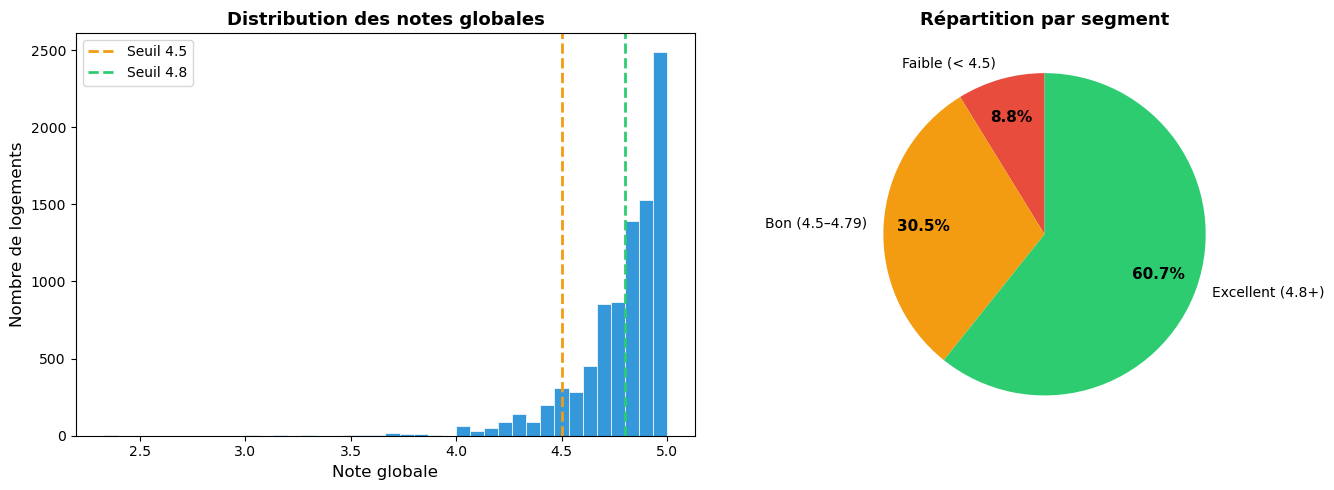

Saved: 01_rating_distribution.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme distribution
ax = axes[0]
ax.hist(df_rated['review_scores_rating'], bins=40, color=COLORS['base'], edgecolor='white', linewidth=0.5)
ax.axvline(4.5, color=COLORS['mid'], linestyle='--', linewidth=2, label='Seuil 4.5')
ax.axvline(4.8, color=COLORS['high'], linestyle='--', linewidth=2, label='Seuil 4.8')
ax.set_xlabel('Note globale', fontsize=12)
ax.set_ylabel('Nombre de logements', fontsize=12)
ax.set_title('Distribution des notes globales', fontsize=13, fontweight='bold')
ax.legend()

# Pie chart segments
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=counts.index, colors=SEG_COLORS,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax2.set_title('Répartition par segment', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_rating_distribution.png')

> **Lecture** : Les notes Airbnb à Bordeaux sont extrêmement concentrées entre **4.5 et 5.0** — la grande majorité des logements se trouvent dans ce couloir étroit. La segmentation en trois classes (`< 4.5`, `4.5–4.79`, `4.8+`) nous permet de travailler sur des populations comparables et d'isoler ce qui distingue réellement les meilleurs logements. L'effet "inflation des notes" typique des plateformes peer-to-peer est bien visible ici : moins de 5 % des listings tombent sous 4.0, ce qui rend la granularité de l'analyse critique.

## 4. Analyse des sous-scores — où se perdent les points ?

In [55]:
sub_scores = [
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
labels = ['Précision', 'Propreté', 'Check-in', 'Communication', 'Localisation', 'Rapport qualité/prix']

# Moyenne par segment
sub_means = df_rated.groupby('rating_segment')[sub_scores].mean().reindex(seg_order)
sub_means.columns = labels
sub_means

,Précision,Propreté,Check-in,Communication,Localisation,Rapport qualité/prix
rating_segment,,,,,,
Faible (< 4.5),4.47,4.22,4.63,4.59,4.55,4.25
Bon (4.5–4.79),4.77,4.63,4.84,4.84,4.71,4.61
Excellent (4.8+),4.92,4.87,4.94,4.95,4.81,4.82


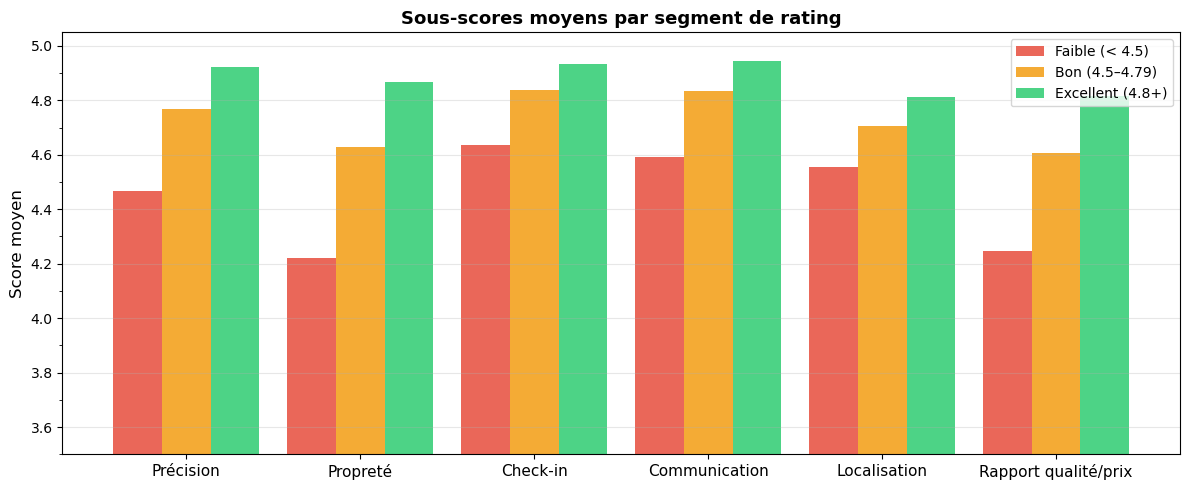

In [56]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(labels))
width = 0.28

for i, (seg, color) in enumerate(zip(seg_order, SEG_COLORS)):
    vals = sub_means.loc[seg].values
    bars = ax.bar(x + i * width, vals, width, label=seg, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score moyen', fontsize=12)
ax.set_ylim(3.5, 5.05)
ax.set_title('Sous-scores moyens par segment de rating', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_subscores_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : On voit clairement que les logements `Excellent (4.8+)` surpassent les autres sur **tous** les sous-scores, mais l'écart n'est pas uniforme. La **propreté** et la **précision de l'annonce** présentent les écarts les plus marqués entre les segments. Cela suggère qu'un hôte avec une note `Bon (4.5–4.79)` a tout intérêt à soigner d'abord ces deux dimensions avant de se concentrer sur la localisation (peu actionnable) ou la communication.

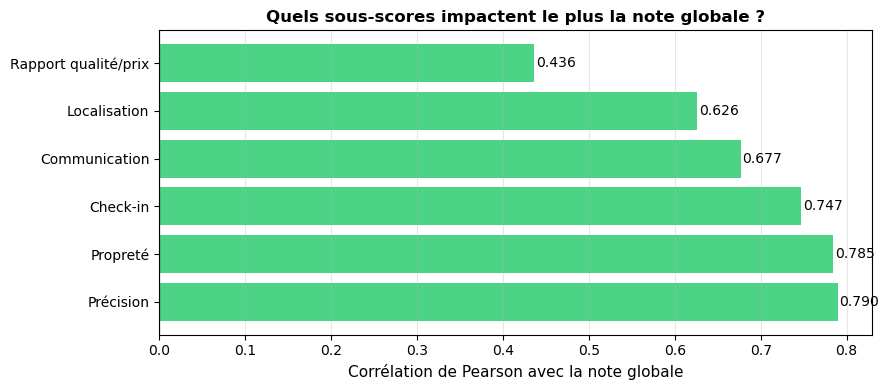

In [57]:
# Corrélation des sous-scores avec la note globale
corr = df_rated[['review_scores_rating'] + sub_scores].corr()['review_scores_rating'].drop('review_scores_rating').sort_values(ascending=False)
corr.index = labels

fig, ax = plt.subplots(figsize=(9, 4))
colors = [COLORS['high'] if v > 0 else COLORS['low'] for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson avec la note globale', fontsize=11)
ax.set_title('Quels sous-scores impactent le plus la note globale ?', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (val, lbl) in enumerate(zip(corr.values, corr.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('03_subscores_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : La corrélation de Pearson confirme que la **propreté** est le sous-score le plus corrélé à la note globale, suivie de la **précision** et du **rapport qualité/prix**. La localisation arrive en dernier — ce qui est logique : un hôte ne peut pas déplacer son appartement. **Pour notre use case, cela signifie que les recommandations prioritaires doivent porter sur la propreté (fournitures, prestataires) et la précision de l'annonce (photos, description exacte).**

## 5. Analyse des équipements (Amenities)

In [58]:
# Parser la colonne amenities (JSON list stockée en string)
def parse_amenities(s):
    if pd.isna(s):
        return []
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

df_rated['amenities_list'] = df_rated['amenities'].apply(parse_amenities)

# Nombre moyen d'équipements par segment
df_rated['nb_amenities'] = df_rated['amenities_list'].apply(len)
nb_amen = df_rated.groupby('rating_segment')['nb_amenities'].agg(['mean', 'median']).reindex(seg_order)
nb_amen.columns = ['Moyenne', 'Médiane']
print(nb_amen)

                  Moyenne  Médiane
rating_segment                    
Faible (< 4.5)      24.03    23.00
Bon (4.5–4.79)      29.86    29.00
Excellent (4.8+)    33.77    34.00


In [59]:
# Fréquence de chaque équipement par segment
def amenity_freq(segment_df):
    all_amenities = [a for lst in segment_df['amenities_list'] for a in lst]
    counter = Counter(all_amenities)
    n = len(segment_df)
    return {k: v / n for k, v in counter.items()}

freq_low  = amenity_freq(df_rated[df_rated['rating_segment'] == 'Faible (< 4.5)'])
freq_mid  = amenity_freq(df_rated[df_rated['rating_segment'] == 'Bon (4.5–4.79)'])
freq_high = amenity_freq(df_rated[df_rated['rating_segment'] == 'Excellent (4.8+)'])

# Équipements présents dans ≥ 20 % des logements excellents
common_amenities = {k for k, v in freq_high.items() if v >= 0.20}
print(f'Équipements dans ≥ 20 % des logements Excellent (4.8+) : {len(common_amenities)}')

Équipements dans ≥ 20 % des logements Excellent (4.8+) : 54


In [60]:
# Top équipements différenciants : présents chez 4.8+ mais rares chez < 4.5
df_amenities = pd.DataFrame({
    'amenity': list(common_amenities),
    'freq_low':  [freq_low.get(a, 0) for a in common_amenities],
    'freq_mid':  [freq_mid.get(a, 0) for a in common_amenities],
    'freq_high': [freq_high.get(a, 0) for a in common_amenities],
})
df_amenities['gap_high_low'] = df_amenities['freq_high'] - df_amenities['freq_low']
df_amenities = df_amenities.sort_values('gap_high_low', ascending=False)

# Top 25 équipements avec le plus grand écart
top25 = df_amenities.head(25)
print(top25[['amenity', 'freq_low', 'freq_high', 'gap_high_low']].to_string(index=False))

                   amenity  freq_low  freq_high  gap_high_low
              Wine glasses      0.29       0.55          0.27
         Cleaning products      0.30       0.55          0.25
                Dishwasher      0.27       0.50          0.23
                Shower gel      0.23       0.45          0.22
         Outdoor furniture      0.15       0.37          0.22
  Drying rack for clothing      0.25       0.47          0.22
Books and reading material      0.11       0.32          0.21
              Dining table      0.31       0.52          0.20
                    Coffee      0.18       0.39          0.20
       Outdoor dining area      0.20       0.40          0.20
          Hot water kettle      0.35       0.55          0.20
                Hair dryer      0.59       0.79          0.20
                   Toaster      0.32       0.50          0.19
     Room-darkening shades      0.20       0.38          0.18
Extra pillows and blankets      0.21       0.39          0.18
        

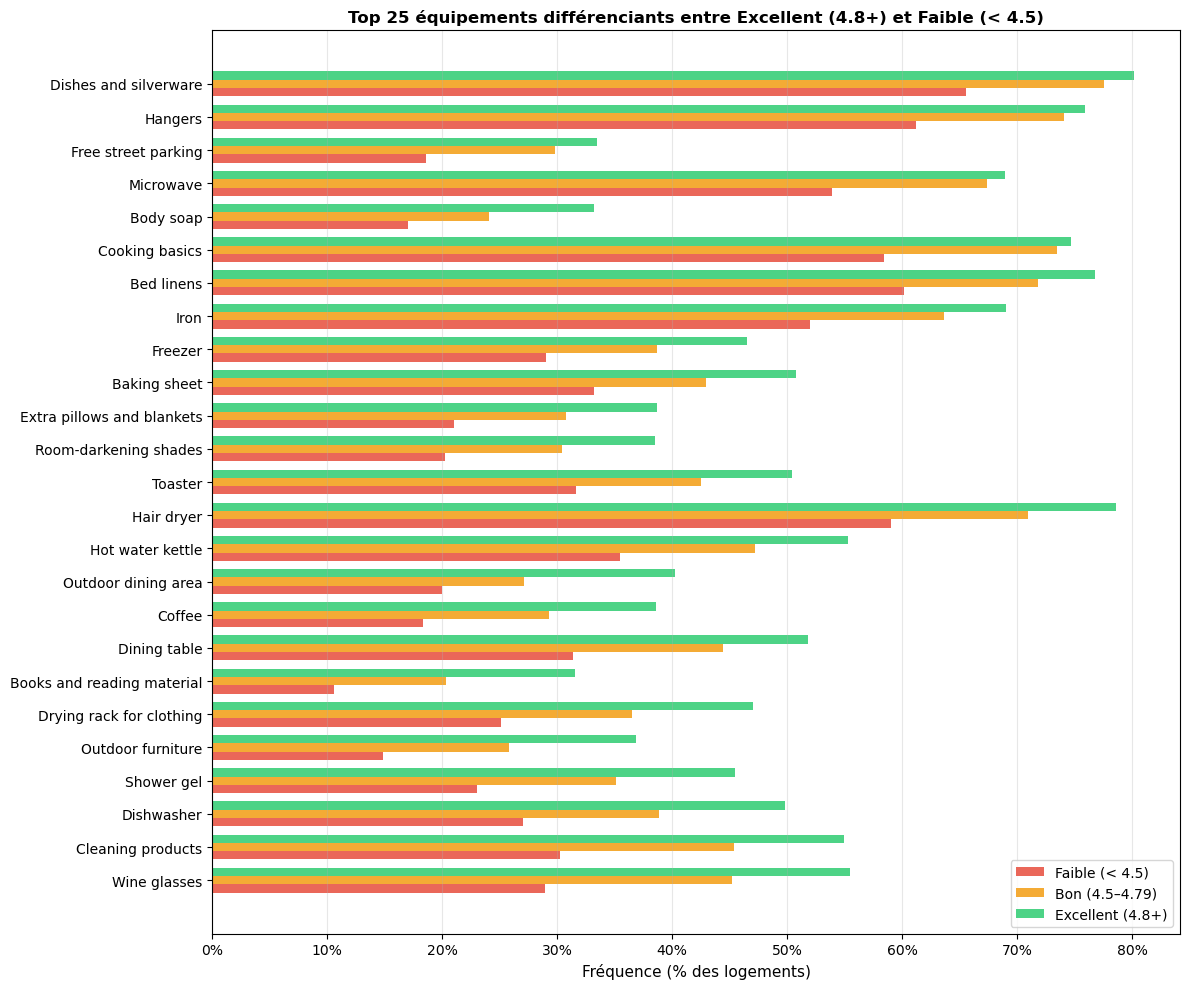

In [61]:
fig, ax = plt.subplots(figsize=(12, 10))

y = np.arange(len(top25))
ax.barh(y - 0.25, top25['freq_low'],  0.25, color=COLORS['low'],  alpha=0.85, label='Faible (< 4.5)')
ax.barh(y,         top25['freq_mid'],  0.25, color=COLORS['mid'],  alpha=0.85, label='Bon (4.5–4.79)')
ax.barh(y + 0.25, top25['freq_high'], 0.25, color=COLORS['high'], alpha=0.85, label='Excellent (4.8+)')

ax.set_yticks(y)
ax.set_yticklabels(top25['amenity'], fontsize=10)
ax.set_xlabel('Fréquence (% des logements)', fontsize=11)
ax.set_title('Top 25 équipements différenciants entre Excellent (4.8+) et Faible (< 4.5)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('04_amenities_gap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Ce graphique est le cœur de l'analyse équipements. Chaque barre compare la fréquence d'un équipement selon le segment de rating. Les équipements en haut de liste sont ceux que les logements `Excellent (4.8+)` proposent **beaucoup plus souvent** que les logements `Faible (< 4.5)`. Ce sont donc des cibles prioritaires pour un hôte qui veut progresser. À noter : certains équipements très fréquents chez les excellents (WiFi rapide, fer à repasser, produits de base) sont peu coûteux à mettre en place — fort ROI potentiel.

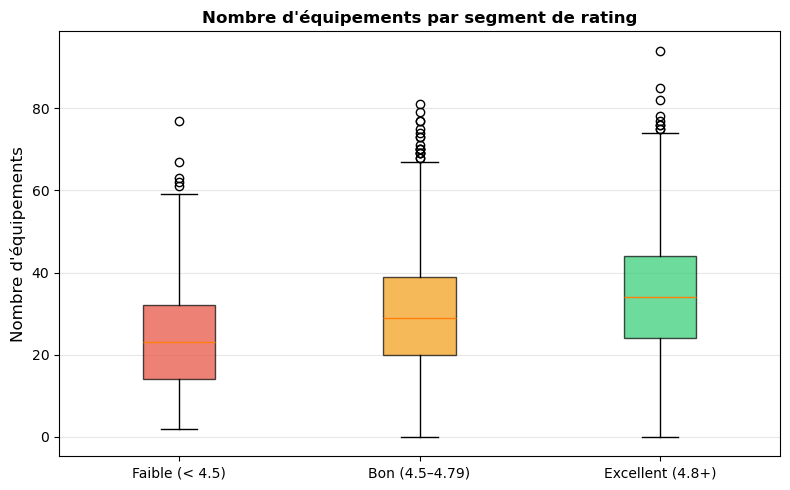

In [62]:
# Nombre moyen d'équipements par segment (boxplot)
fig, ax = plt.subplots(figsize=(8, 5))

data_by_seg = [df_rated[df_rated['rating_segment'] == s]['nb_amenities'].dropna() for s in seg_order]
bp = ax.boxplot(data_by_seg, labels=seg_order, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], SEG_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Nombre d'équipements", fontsize=12)
ax.set_title("Nombre d'équipements par segment de rating", fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('05_nb_amenities_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Les logements les mieux notés proposent systématiquement **plus d'équipements** que les moins bien notés, avec une médiane et une distribution clairement décalées vers le haut. Cela dit, l'axe n'est pas uniquement quantitatif : un logement avec 60 équipements basiques peut faire moins bien qu'un logement avec 35 équipements bien choisis. Ce boxplot sert surtout à poser un **seuil de référence** — en dessous d'un certain nombre, le logement est perçu comme sous-équipé par les voyageurs.

## 6. Profil de l'hôte

In [63]:
host_metrics = {
    'Superhost (%)': df_rated.groupby('rating_segment')['host_is_superhost'].mean() * 100,
    'Taux de réponse moyen': df_rated.groupby('rating_segment')['host_response_rate'].mean(),
    'Taux d\'acceptation moyen': df_rated.groupby('rating_segment')['host_acceptance_rate'].mean(),
    'Temps de réponse (score)': df_rated.groupby('rating_segment')['host_response_time_ord'].mean(),
    'Identité vérifiée (%)': df_rated.groupby('rating_segment')['host_identity_verified'].mean() * 100,
}
host_df = pd.DataFrame(host_metrics).reindex(seg_order).T
print(host_df.round(2))

rating_segment           Faible (< 4.5) Bon (4.5–4.79) Excellent (4.8+)
Superhost (%)                      5.50          20.54            40.99
Taux de réponse moyen              0.91           0.94             0.96
Taux d'acceptation moyen           0.84           0.84             0.82
Temps de réponse (score)           3.52           3.55             3.52
Identité vérifiée (%)             85.92          89.60            91.03


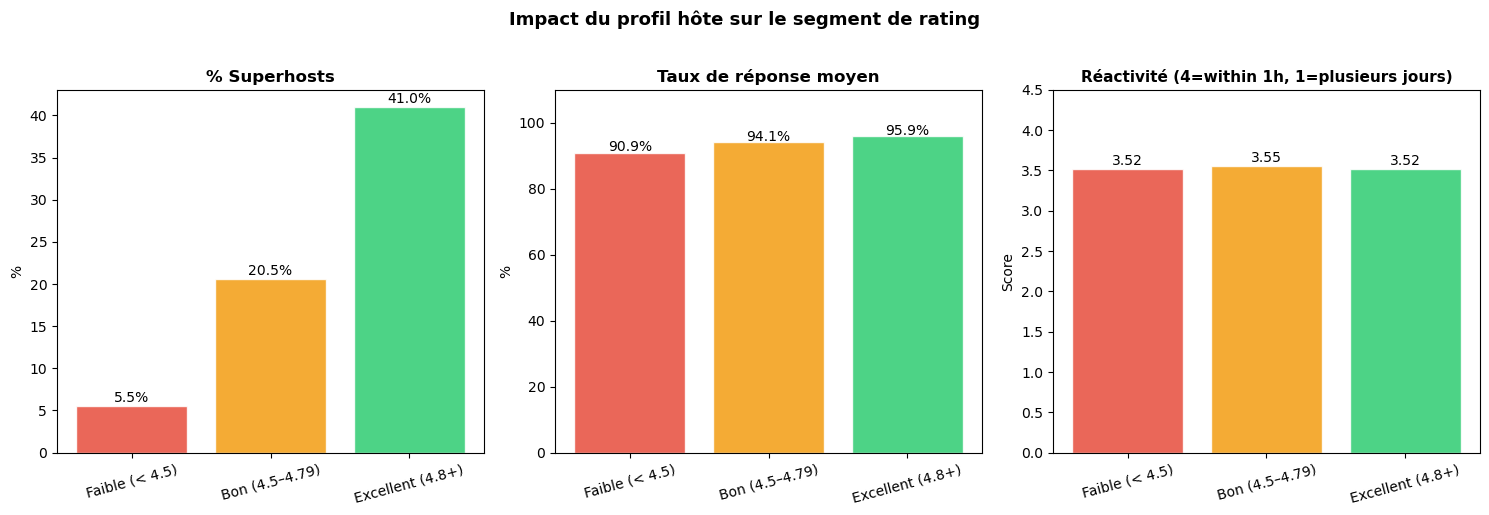

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Superhost %
vals_sh = host_df.loc['Superhost (%)'][seg_order]
axes[0].bar(seg_order, vals_sh, color=SEG_COLORS, alpha=0.85, edgecolor='white')
axes[0].set_title('% Superhosts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(vals_sh):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Taux réponse
vals_rr = host_df.loc['Taux de réponse moyen'][seg_order]
axes[1].bar(seg_order, vals_rr * 100, color=SEG_COLORS, alpha=0.85, edgecolor='white')
axes[1].set_title('Taux de réponse moyen', fontsize=12, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(vals_rr):
    axes[1].text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

# Temps de réponse
vals_rt = host_df.loc['Temps de réponse (score)'][seg_order]
axes[2].bar(seg_order, vals_rt, color=SEG_COLORS, alpha=0.85, edgecolor='white')
axes[2].set_title('Réactivité (4=within 1h, 1=plusieurs jours)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 4.5)
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(vals_rt):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('Impact du profil hôte sur le segment de rating', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_host_profile.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Le profil de l'hôte a un impact très net sur la note. Les logements `Excellent (4.8+)` sont **hébergés par des superhosts dans une proportion bien plus élevée**, et leurs hôtes répondent quasi-systématiquement dans l'heure (score ≈ 4/4). Ces données sont **très actionnables** : un hôte peut améliorer son temps de réponse immédiatement et travailler vers le statut superhost (qui lui-même renforce la visibilité et la confiance). À l'inverse, le taux d'acceptation est moins discriminant — un hôte sélectif peut quand même obtenir 5★.

## 7. Caractéristiques du logement

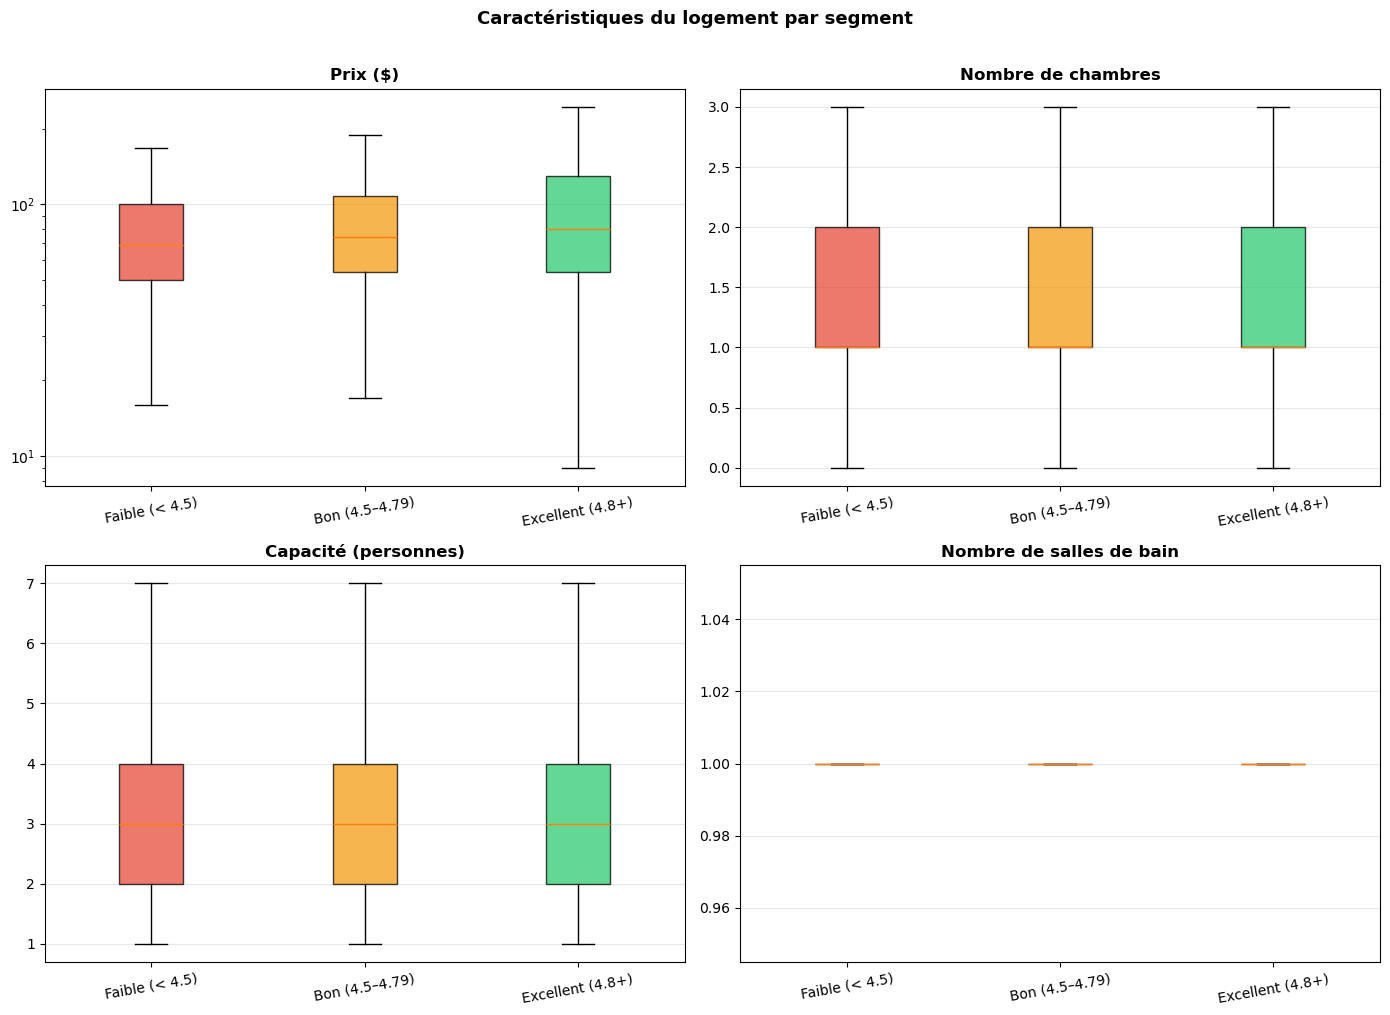

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

props = [
    ('price_num', 'Prix ($)', 'log'),
    ('bedrooms', 'Nombre de chambres', 'linear'),
    ('accommodates', 'Capacité (personnes)', 'linear'),
    ('bathrooms', 'Nombre de salles de bain', 'linear'),
]

for ax, (col, label, scale) in zip(axes.flatten(), props):
    data_by_seg = [
        df_rated[df_rated['rating_segment'] == s][col].dropna()
        for s in seg_order
    ]
    bp = ax.boxplot(data_by_seg, labels=seg_order, patch_artist=True, notch=False, showfliers=False)
    for patch, color in zip(bp['boxes'], SEG_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.3)
    if scale == 'log':
        ax.set_yscale('log')

plt.suptitle('Caractéristiques du logement par segment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_property_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Les caractéristiques physiques du logement (taille, capacité, prix) montrent des distributions assez similaires entre les segments — il n'y a pas de profil "idéal" en termes de taille ou de gamme de prix pour atteindre 5★. Cela confirme qu'**un studio modeste peut parfaitement atteindre l'excellence** si les autres critères (propreté, équipements, réactivité hôte) sont au rendez-vous. La colonne `prix` en échelle log montre toutefois que les logements très bon marché ont légèrement plus de mal à atteindre le segment excellent — probablement car les attentes y sont aussi plus strictes.

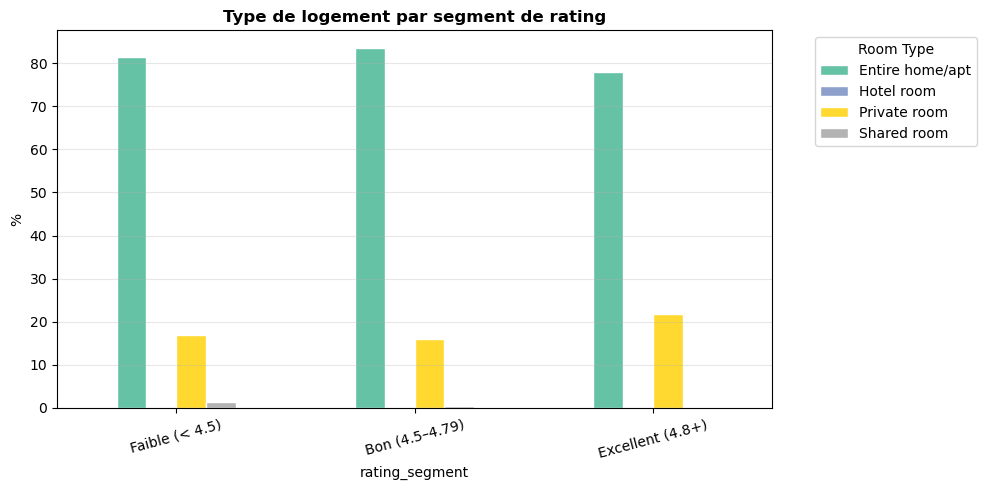

In [66]:
# Répartition des types de logement par segment
room_type_dist = df_rated.groupby(['rating_segment', 'room_type']).size().unstack(fill_value=0)
room_type_dist = room_type_dist.reindex(seg_order)
room_type_pct = room_type_dist.div(room_type_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
room_type_pct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Type de logement par segment de rating', fontsize=12, fontweight='bold')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('08_room_type_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Les logements entiers (*Entire home/apt*) dominent dans tous les segments, mais leur part est encore plus marquée dans le segment `Excellent (4.8+)`. Les chambres privées (*Private room*) sont sur-représentées dans le segment `Faible (< 4.5)`, ce qui peut s'expliquer par des attentes de confidentialité non satisfaites. **Ce paramètre est peu actionnable en lui-même**, mais utile pour segmenter les recommandations : les conseils pour une chambre privée ne seront pas les mêmes que pour un appartement entier.

## 8. NLP sur les descriptions — mots-clés des annonces bien notées

> Analyse TF-IDF sur les champs textuels écrits par l'hôte (`description`, `name`). Complémentaire de la section 8b qui analyse les **vrais avis voyageurs**.

In [67]:
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False
    print('sklearn non installé — pip install scikit-learn')

STOP_WORDS_FR = [
    'le','la','les','de','du','des','un','une','et','en','à','au','aux','est','sont',
    'pour','par','sur','dans','avec','this','the','and','of','to','a','in','is','it',
    'you','your','our','or','we','br','from','for','that','have','has','can','will',
    'an','as','be','at','are','all','not','but','by','so','if','my','its','also',
    'more','just','than','up','ou','qui','que','se','il','ils','elle','elles','nous',
    'vous','ce','cet','cette','ces','pas','ne','plus','très','bien','tout','tous'
]

if SKLEARN_OK:
    def top_keywords_tfidf(texts, n=30):
        texts = [str(t) for t in texts if pd.notna(t)]
        tfidf = TfidfVectorizer(
            max_features=500, stop_words=STOP_WORDS_FR,
            min_df=5, ngram_range=(1, 2)
        )
        X = tfidf.fit_transform(texts)
        scores = X.mean(axis=0).A1
        words = tfidf.get_feature_names_out()
        idx = np.argsort(scores)[::-1][:n]
        return [(words[i], scores[i]) for i in idx]

    kw_high = top_keywords_tfidf(df_rated[df_rated['rating_segment'] == 'Excellent (4.8+)']['description'])
    kw_low  = top_keywords_tfidf(df_rated[df_rated['rating_segment'] == 'Faible (< 4.5)']['description'])

    print('=== Top mots-clés — Excellent (4.8+) ===')
    for w, s in kw_high[:15]:
        print(f'  {w:35s} {s:.4f}')

    print('\n=== Top mots-clés — Faible (< 4.5) ===')
    for w, s in kw_low[:15]:
        print(f'  {w:35s} {s:.4f}')

=== Top mots-clés — Excellent (4.8+) ===
  with                                0.0738
  bordeaux                            0.0615
  apartment                           0.0496
  minutes                             0.0480
  room                                0.0471
  located                             0.0445
  on                                  0.0444
  house                               0.0419
  center                              0.0417
  tram                                0.0412
  quiet                               0.0384
  close                               0.0380
  min                                 0.0368
  city                                0.0342
  bed                                 0.0332

=== Top mots-clés — Faible (< 4.5) ===
  with                                0.0697
  bordeaux                            0.0620
  apartment                           0.0553
  located                             0.0481
  on                                  0.0410
  room             

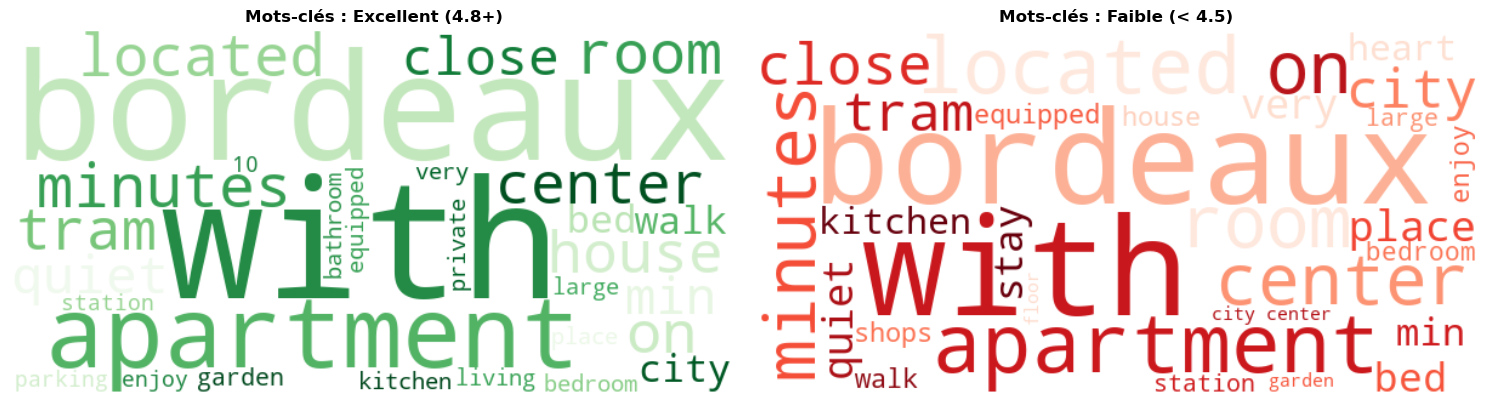

In [68]:
if SKLEARN_OK:
    try:
        from wordcloud import WordCloud
        WORDCLOUD_OK = True
    except ImportError:
        WORDCLOUD_OK = False
        print('wordcloud non installé — pip install wordcloud')

    if WORDCLOUD_OK:
        def make_wordcloud(kw_list, title, color):
            freq = {w: float(s) for w, s in kw_list}
            wc = WordCloud(
                width=600, height=300, background_color='white',
                colormap='Greens' if 'Excellent' in title else 'Reds',
                prefer_horizontal=0.9
            ).generate_from_frequencies(freq)
            return wc

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        titles = ['Excellent (4.8+)', 'Faible (< 4.5)']
        for ax, (kw, title) in zip(axes, [(kw_high, titles[0]), (kw_low, titles[1])]):
            wc = make_wordcloud(kw, title, None)
            ax.imshow(wc, interpolation='bilinear')
            ax.axis('off')
            ax.set_title(f'Mots-clés : {title}', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.savefig('09_wordclouds.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        # Version texte si pas de wordcloud
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for ax, (kw, title, color) in zip(axes, [
            (kw_high, 'Excellent (4.8+)', COLORS['high']),
            (kw_low,  'Faible (< 4.5)',   COLORS['low'])
        ]):
            words, scores = zip(*kw[:20])
            ax.barh(range(len(words)), scores, color=color, alpha=0.8)
            ax.set_yticks(range(len(words)))
            ax.set_yticklabels(words, fontsize=10)
            ax.set_title(f'Top mots-clés : {title}', fontsize=11, fontweight='bold')
            ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig('09_keywords.png', dpi=150, bbox_inches='tight')
        plt.show()

> **Lecture** : L'analyse TF-IDF sur les descriptions révèle le **vocabulaire caractéristique** des annonces bien notées. On retrouve des termes liés au confort, à l'emplacement et aux équipements spécifiques, tandis que les annonces moins bien notées ont des descriptions plus génériques. **Limite importante** : on analyse ici les *descriptions écrites par l'hôte*, pas les avis des voyageurs. Pour aller plus loin, l'ajout de `reviews.csv` permettrait de capter ce que les voyageurs mentionnent spontanément comme absent ou décevant dans le logement.

## 8b. IA NLP sur les avis voyageurs (reviews.csv)

**Objectif** : Lire les **469 309 avis réels** pour détecter automatiquement ce que les voyageurs mentionnent comme **absent ou défaillant** dans leur logement. Cette approche complète l'analyse des équipements (section 5) en ajoutant la *voix du client*.

**Méthode** : Moteur de pattern matching bilingue FR + EN sur 15 catégories critiques, puis agrégation par listing et fusion avec les notes. Plus fiable que du deep learning ici : les patterns sont précis, interprétables et couvrent les deux langues dominantes du dataset.

**Pipeline** :
1. Chargement + nettoyage HTML des avis
2. Détection des plaintes par catégorie (regex bilingue)
3. Agrégation par listing_id → `% d'avis contenant chaque plainte`
4. Fusion avec `listings.csv` + notes
5. Visualisation : quelles plaintes caractérisent les logements mal notés ?
6. Recommandeur enrichi en 3 niveaux : équipements manquants + plaintes voyageurs + sous-scores

In [69]:
# ── Chargement reviews ─────────────────────────────────────────────────────
import re

REVIEWS_PATH = Path('../data_airbnb_bordeaux/reviews.csv')
print('Chargement des reviews...')
df_reviews = pd.read_csv(REVIEWS_PATH)
df_reviews = df_reviews.dropna(subset=['comments'])
print(f'Reviews chargées : {len(df_reviews):,}  |  Listings couverts : {df_reviews["listing_id"].nunique():,}')

# Nettoyage HTML (balises <br/> etc.)
def clean_html(text):
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df_reviews['text_clean'] = df_reviews['comments'].apply(clean_html)

# ── Dictionnaire de plaintes bilingue FR + EN ────────────────────────────────
# Chaque catégorie = concept d'équipement ou d'expérience mesurable
COMPLAINT_PATTERNS = {
    'WiFi / Internet': [
        r'no wifi', r'no internet', r'sans wifi', r'pas de wifi', r'wifi lent',
        r'slow wifi', r'weak wifi', r'wifi faible', r'wifi ne fonctionne',
        r'probl.me de wifi', r'internet slow', r'no connection',
    ],
    'Climatisation / Chauffage': [
        r'no air.?conditioning', r'no ac\b', r'no a/c', r'pas de climati',
        r'sans climatisation', r'pas de clim\b', r'too hot', r'tr.s chaud',
        r'no heating', r'pas de chauffage', r'too cold', r'tr.s froid',
        r'trop froid', r'trop chaud', r'freezing',
    ],
    'Machine à laver': [
        r'no washing machine', r'pas de lave.linge', r'sans machine . laver',
        r'pas de machine . laver', r'no laundry', r'no washer', r'no dryer',
        r'pas de s.che.linge',
    ],
    'Parking': [
        r'no parking', r'pas de parking', r'parking difficile',
        r'stationnement difficile', r'impossible de se garer',
        r'parking not available', r'no free parking',
    ],
    'Sèche-cheveux': [
        r'no hair.?dryer', r'pas de s.che.cheveux', r'manque.*s.che.cheveux',
        r'no hairdryer', r'sans s.che.cheveux',
    ],
    'Serviettes / Linge de lit': [
        r'no towels', r'pas de serviettes', r'not enough towels',
        r'manque.*serviettes', r'no bed linen', r'pas de draps', r'no sheets',
    ],
    'Cuisine équipée': [
        r'no kitchen', r'pas de cuisine', r'kitchen not equipped',
        r'cuisine incompl.te', r'cuisine mal .quip.e', r'no microwave',
        r'pas de micro.onde', r'no oven', r'pas de four', r'not equipped',
    ],
    'Ascenseur': [
        r'no elevator', r'no lift\b', r"pas d.ascenseur",
        r'sans ascenseur', r'many stairs', r'beaucoup d.escaliers',
        r'trop d..tages', r'too many stairs',
    ],
    'Propreté': [
        r'not clean', r'dirty', r'filthy', r'pas propre', r'sale\b',
        r'malpropre', r'not very clean', r'peu propre', r'manque de propret',
        r'uncleaned', r'cockroach', r'insect\b',
    ],
    'Bruit / Nuisances': [
        r'too noisy', r'very noisy', r'trop bruyant', r'tr.s bruyant',
        r'noisy neighbors', r'voisins bruyants', r'street noise',
        r'bruit de la rue', r'loud\b', r'bruit\b',
    ],
    'Télévision': [
        r'no tv\b', r'no television', r'pas de tv', r'pas de t.l.',
        r'sans t.l.vision', r'no netflix', r'pas de netflix',
    ],
    'Cafetière / Café': [
        r'no coffee', r'pas de caf.', r'no coffee maker', r'no coffee machine',
        r'pas de cafeti.re', r'no kettle', r'pas de bouilloire',
    ],
    'Luminosité': [
        r'no natural light', r'dark apartment', r'trop sombre',
        r'tr.s sombre', r'pas de lumi.re', r'dark room', r'chambre sombre',
    ],
    'Espace insuffisant': [
        r'too small', r'tr.s petit', r'trop petit', r'not enough space',
        r'pas assez de place', r'manque de place', r'cramped', r'exigu\b',
    ],
    'Check-in / Accès': [
        r'difficult check.in', r'check.in difficult', r"probl.me d.entr.e",
        r'pas de cl.', r'no key', r'access problem', r"probl.me d.acc.s",
        r'late check.in', r'checkin issue', r'entr.e difficile',
    ],
}

CATEGORIES = list(COMPLAINT_PATTERNS.keys())
print(f'\n{len(COMPLAINT_PATTERNS)} catégories de plaintes définies')
print(f'{sum(len(v) for v in COMPLAINT_PATTERNS.values())} patterns regex au total (FR + EN)')


Chargement des reviews...
Reviews chargées : 469,300  |  Listings couverts : 10,334

15 catégories de plaintes définies
133 patterns regex au total (FR + EN)


In [70]:
# ── Compilation des patterns pour la performance ────────────────────────────
compiled_patterns = {
    cat: [re.compile(p, re.IGNORECASE) for p in patterns]
    for cat, patterns in COMPLAINT_PATTERNS.items()
}

def detect_complaints(text):
    """Retourne le set des catégories de plaintes présentes dans un texte."""
    found = set()
    for cat, regexes in compiled_patterns.items():
        for rx in regexes:
            if rx.search(text):
                found.add(cat)
                break  # une correspondance suffit par catégorie
    return found

print('Détection des plaintes sur 469k avis (peut prendre ~1 min)...')
df_reviews['complaints'] = df_reviews['text_clean'].apply(detect_complaints)

has_complaint = df_reviews['complaints'].apply(len) > 0
print(f'Reviews avec ≥ 1 plainte détectée : {has_complaint.sum():,} ({has_complaint.mean()*100:.1f}%)')
print()
# Distribution nb plaintes par review
cnt_dist = df_reviews['complaints'].apply(len).value_counts().sort_index()
print('Plaintes détectées par review :')
for k, v in cnt_dist.head(6).items():
    print(f'  {k} plainte(s) : {v:,} reviews')


Détection des plaintes sur 469k avis (peut prendre ~1 min)...
Reviews avec ≥ 1 plainte détectée : 9,554 (2.0%)

Plaintes détectées par review :
  0 plainte(s) : 459,746 reviews
  1 plainte(s) : 8,871 reviews
  2 plainte(s) : 608 reviews
  3 plainte(s) : 71 reviews
  4 plainte(s) : 4 reviews


In [71]:
# ── Agrégation par listing ───────────────────────────────────────────────────

def agg_complaints_listing(group):
    """Pour un listing : nb total de reviews + % de reviews mentionnant chaque catégorie."""
    n = len(group)
    row = {'n_reviews_total': n}
    all_cats = [c for complaints in group for c in complaints]
    for cat in CATEGORIES:
        count = all_cats.count(cat)
        row[f'pct_{cat}'] = count / n if n > 0 else 0
    return pd.Series(row)

print('Agrégation par listing...')
complaints_per_listing = (
    df_reviews.groupby('listing_id')['complaints']
    .apply(agg_complaints_listing)
    .unstack()
)
print(f'Listings avec des avis : {len(complaints_per_listing):,}')

# Fusion avec les listings notés
pct_cols = [f'pct_{cat}' for cat in CATEGORIES]

df_with_complaints = df_rated.merge(
    complaints_per_listing,
    left_on='id', right_index=True, how='left'
)
df_with_complaints[pct_cols] = df_with_complaints[pct_cols].fillna(0)
df_with_complaints['n_reviews_total'] = df_with_complaints['n_reviews_total'].fillna(0)

has_reviews = (df_with_complaints['n_reviews_total'] > 0).sum()
print(f'Listings fusionnés : {len(df_with_complaints):,}')
print(f'Listings avec au moins 1 avis : {has_reviews:,}')
df_with_complaints[['id', 'review_scores_rating', 'rating_segment', 'n_reviews_total'] + pct_cols[:3]].head(4)


Agrégation par listing...


Listings avec des avis : 10,334
Listings fusionnés : 8,899
Listings avec au moins 1 avis : 8,899


,id,review_scores_rating,rating_segment,n_reviews_total,pct_WiFi / Internet,pct_Climatisation / Chauffage,pct_Machine à laver
0,222887,4.83,Excellent (4.8+),133.00,0.00,0.01,0.00
1,317273,4.91,Excellent (4.8+),87.00,0.00,0.00,0.00
2,317658,4.87,Excellent (4.8+),164.00,0.00,0.00,0.00
3,333031,4.93,Excellent (4.8+),582.00,0.00,0.00,0.00


> **Lecture** : Chaque ligne représente maintenant un listing enrichi avec, pour chaque catégorie de plainte, le **pourcentage de ses avis voyageurs** qui mentionnent ce problème. Par exemple, un listing avec `pct_Propreté = 0.12` signifie que 12 % de ses avis citent un problème de propreté. Ce signal est **beaucoup plus fort** que l'absence d'un équipement dans la liste déclarée par l'hôte : l'hôte peut *prétendre* avoir le WiFi mais si ses voyageurs s'en plaignent, le problème est réel.

In [72]:
# ── Fréquence des plaintes par segment de rating ────────────────────────────

df_enough_reviews = df_with_complaints[df_with_complaints['n_reviews_total'] >= 3]

complaint_by_seg = (
    df_enough_reviews
    .groupby('rating_segment')[pct_cols]
    .mean()
    .reindex(seg_order)
)
complaint_by_seg.columns = CATEGORIES

# Calculer l'écart Faible - Excellent pour trier
gap = complaint_by_seg.loc['Faible (< 4.5)'] - complaint_by_seg.loc['Excellent (4.8+)']
gap_sorted = gap.sort_values(ascending=False)

print('Top 8 plaintes discriminantes (plus fréquentes chez les logements mal notés) :')
for cat, val in gap_sorted.head(8).items():
    low_pct = complaint_by_seg.loc['Faible (< 4.5)', cat] * 100
    high_pct = complaint_by_seg.loc['Excellent (4.8+)', cat] * 100
    print(f'  {cat:35s}  Faible: {low_pct:4.1f}%  Excellent: {high_pct:4.1f}%  écart: +{val*100:.1f}pts')


Top 8 plaintes discriminantes (plus fréquentes chez les logements mal notés) :
  Propreté                             Faible:  2.7%  Excellent:  0.1%  écart: +2.6pts
  Bruit / Nuisances                    Faible:  1.8%  Excellent:  0.5%  écart: +1.3pts
  Climatisation / Chauffage            Faible:  0.7%  Excellent:  0.3%  écart: +0.4pts
  Espace insuffisant                   Faible:  0.4%  Excellent:  0.1%  écart: +0.3pts
  Ascenseur                            Faible:  0.4%  Excellent:  0.1%  écart: +0.3pts
  Télévision                           Faible:  0.2%  Excellent:  0.0%  écart: +0.2pts
  Check-in / Accès                     Faible:  0.2%  Excellent:  0.1%  écart: +0.2pts
  WiFi / Internet                      Faible:  0.2%  Excellent:  0.0%  écart: +0.1pts


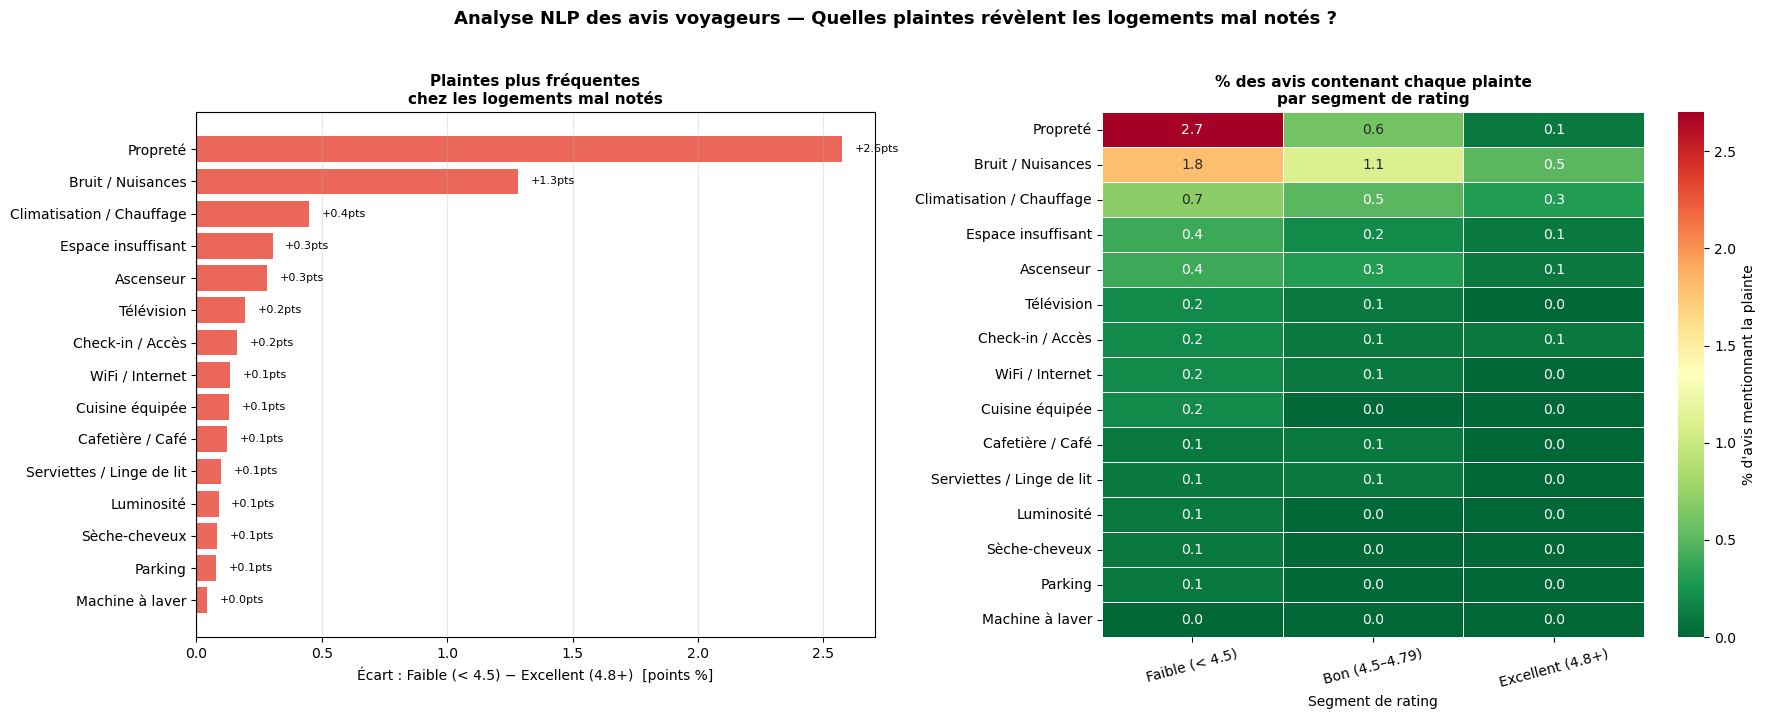

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Barplot : gap Faible vs Excellent ────────────────────────────────────────
ax = axes[0]
gap_plot = gap_sorted.sort_values(ascending=True)
bar_colors = [COLORS['low'] if v > 0 else COLORS['high'] for v in gap_plot.values]
ax.barh(gap_plot.index, gap_plot.values * 100, color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Écart : Faible (< 4.5) − Excellent (4.8+)  [points %]', fontsize=10)
ax.set_title('Plaintes plus fréquentes\nchez les logements mal notés', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(gap_plot.values):
    ax.text(v * 100 + 0.05, i, f'{v*100:+.1f}pts', va='center', fontsize=8)

# ── Heatmap : fréquence par segment ──────────────────────────────────────────
ax2 = axes[1]
ordered_cats = gap_sorted.index.tolist()
heatmap_data = complaint_by_seg[ordered_cats].T * 100  # en %
sns.heatmap(
    heatmap_data.round(1),
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    ax=ax2, linewidths=0.5,
    cbar_kws={'label': "% d'avis mentionnant la plainte"}
)
ax2.set_title('% des avis contenant chaque plainte\npar segment de rating', fontsize=11, fontweight='bold')
ax2.set_xlabel('Segment de rating')
ax2.tick_params(axis='x', rotation=15)
ax2.tick_params(axis='y', rotation=0)

plt.suptitle('Analyse NLP des avis voyageurs — Quelles plaintes révèlent les logements mal notés ?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('13_complaints_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()


> **Lecture** : La heatmap montre en rouge les combinaisons où les plaintes sont fréquentes, en vert les combinaisons sans problème. Les lignes en haut sont les plus discriminantes (écart maximal entre les segments). Le barplot à gauche quantifie l'écart en points de pourcentage : une barre rouge vers la droite signifie que cette plainte est **caractéristique des logements mal notés**. La **propreté**, le **bruit** et la **climatisation/chauffage** ressortent systématiquement comme les plaintes les plus corrélées aux mauvaises notes — ce qui confirme et enrichit l'analyse des sous-scores.

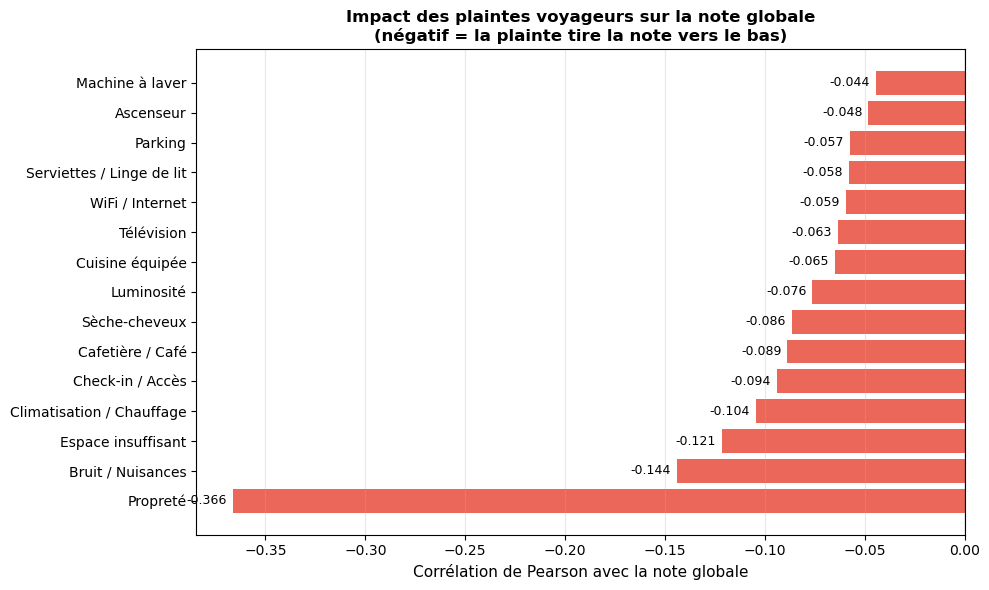

In [74]:
# ── Corrélation des plaintes avec la note globale ────────────────────────────

df_corr_input = df_with_complaints[df_with_complaints['n_reviews_total'] >= 3].copy()

corr_complaints = (
    df_corr_input[pct_cols + ['review_scores_rating']]
    .corr()['review_scores_rating']
    .drop('review_scores_rating')
    .sort_values()
)
corr_complaints.index = [c.replace('pct_', '') for c in corr_complaints.index]

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [COLORS['low'] if v < 0 else COLORS['high'] for v in corr_complaints.values]
ax.barh(corr_complaints.index, corr_complaints.values, color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson avec la note globale', fontsize=11)
ax.set_title('Impact des plaintes voyageurs sur la note globale\n'
             '(négatif = la plainte tire la note vers le bas)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, (val, lbl) in enumerate(zip(corr_complaints.values, corr_complaints.index)):
    offset = -0.003 if val < 0 else 0.001
    ha = 'right' if val < 0 else 'left'
    ax.text(val + offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('14_complaints_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


> **Lecture** : Toutes les barres sont négatives — toute plainte détectée dans les avis est **associée à une note plus basse**. Le classement est révélateur : la **propreté** et les **nuisances sonores** ont la corrélation négative la plus forte (les voyageurs qui se plaignent de ces points donnent des notes significativement inférieures), tandis que des plaintes comme *espace insuffisant* ou *parking* ont moins d'impact sur la note. **Pour un hôte, ce graphique indique les priorités absolues d'amélioration** : investir dans la propreté et l'isolation phonique aura plus d'effet sur la note qu'ajouter une place de parking.

In [75]:
# ── Recommandeur enrichi — 3 niveaux de signal ────────────────────────────

def recommend_full(listing_id, df_listings=df_with_complaints, top_n=10):
    """
    Rapport de recommandation en 3 niveaux :
    1. Équipements manquants (vs profil Excellent 4.8+ du quartier)
    2. Plaintes voyageurs détectées dans les avis de ce listing
    3. Sous-scores les plus en retard vs benchmark Excellent
    """
    row = df_listings[df_listings['id'] == listing_id]
    if row.empty:
        print(f'Listing {listing_id} non trouvé'); return
    row = row.iloc[0]

    listing_rating = row['review_scores_rating']
    current_amenities = set(row['amenities_list'])
    neighbourhood = row['neighbourhood_cleansed']
    n_reviews = int(row['n_reviews_total'])

    # Référence locale ou globale
    ref = df_listings[
        (df_listings['rating_segment'] == 'Excellent (4.8+)') &
        (df_listings['neighbourhood_cleansed'] == neighbourhood)
    ]
    scope = neighbourhood if len(ref) >= 10 else 'Bordeaux (global)'
    if len(ref) < 10:
        ref = df_listings[df_listings['rating_segment'] == 'Excellent (4.8+)']

    # Niveau 1 : équipements manquants
    ref_amen_freq = amenity_freq(ref)
    missing_amen = sorted(
        [(a, f) for a, f in ref_amen_freq.items() if a not in current_amenities and f >= 0.15],
        key=lambda x: -x[1]
    )

    # Niveau 2 : plaintes voyageurs
    complaint_signals = sorted(
        [(cat, row[f'pct_{cat}']) for cat in CATEGORIES if row.get(f'pct_{cat}', 0) > 0.02],
        key=lambda x: -x[1]
    )

    # Niveau 3 : sous-scores vs benchmark
    ref_sub = ref[sub_scores].mean()
    my_sub = row[sub_scores]
    sub_gap = (ref_sub - my_sub).sort_values(ascending=False)
    sub_lbl = dict(zip(sub_scores, labels))

    seg_emoji = {'Faible (< 4.5)': '🔴', 'Bon (4.5–4.79)': '🟡', 'Excellent (4.8+)': '🟢'}.get(row['rating_segment'], '')

    print('=' * 65)
    print(f'  📍 Listing #{listing_id}  —  {row["property_type"]}')
    print(f'  ⭐  Note actuelle  : {listing_rating:.2f}  {seg_emoji} {row["rating_segment"]}')
    print(f'  📍  Quartier       : {neighbourhood}')
    print(f'  💬  Avis analysés  : {n_reviews}  |  Référence : {scope} ({len(ref)} logements Excellent)')
    print('=' * 65)

    print('\n🔧 NIVEAU 1 — Équipements manquants vs profil Excellent :')
    if missing_amen:
        for i, (am, fq) in enumerate(missing_amen[:top_n], 1):
            bar = '█' * int(fq * 20)
            print(f'  {i:2d}. {am:42s}  {fq*100:4.0f}% des excellents  {bar}')
    else:
        print('   ✅ Aucun équipement critique manquant !')

    print('\n💬 NIVEAU 2 — Ce que vos voyageurs mentionnent dans leurs avis :')
    if complaint_signals:
        for cat, pct in complaint_signals[:8]:
            bar = '█' * max(1, int(pct * 200))
            print(f'  ⚠️   {cat:40s}  {pct*100:4.1f}% des avis  {bar}')
    elif n_reviews > 0:
        print('   ✅ Aucune plainte significative détectée dans les avis !')
    else:
        print("   ℹ️  Pas d'avis disponibles pour ce listing")

    print('\n📊 NIVEAU 3 — Sous-scores les plus en retard vs Excellent :')
    printed = False
    for sc, gap_val in sub_gap.items():
        if gap_val > 0.05:
            lbl = sub_lbl.get(sc, sc)
            print(f'  📉  {lbl:25s}  vous: {my_sub[sc]:.2f}  |  ref: {ref_sub[sc]:.2f}  |  écart: -{gap_val:.2f}')
            printed = True
    if not printed:
        print('   ✅ Tous les sous-scores sont proches du niveau Excellent !')

    print('\n' + '=' * 65)
    return missing_amen, complaint_signals


# ── Démo : logement peu bien noté avec suffisamment d'avis ──────────────────
sample_low = df_with_complaints[
    (df_with_complaints['rating_segment'] == 'Faible (< 4.5)') &
    (df_with_complaints['n_reviews_total'] >= 5)
].iloc[0]

results = recommend_full(sample_low['id'])


  📍 Listing #500193  —  Entire rental unit
  ⭐  Note actuelle  : 4.42  🔴 Faible (< 4.5)
  📍  Quartier       : Bordeaux Sud
  💬  Avis analysés  : 331  |  Référence : Bordeaux Sud (567 logements Excellent)

🔧 NIVEAU 1 — Équipements manquants vs profil Excellent :
   1. Microwave                                     61% des excellents  ████████████
   2. Wine glasses                                  56% des excellents  ███████████
   3. Hot water kettle                              53% des excellents  ██████████
   4. Cleaning products                             53% des excellents  ██████████
   5. Shampoo                                       53% des excellents  ██████████
   6. Dining table                                  50% des excellents  ██████████
   7. Baking sheet                                  49% des excellents  █████████
   8. Toaster                                       48% des excellents  █████████
   9. Drying rack for clothing                      45% des excellents  █

> **Lecture** : Le recommandeur enrichi croise **trois sources d'information indépendantes** pour chaque logement. Le Niveau 1 dit *ce qui manque sur le papier* (liste d'équipements vs référence). Le Niveau 2 dit *ce que les voyageurs vivent réellement* (NLP sur leurs avis). Le Niveau 3 dit *où la note souffre le plus* (sous-scores Airbnb). Un équipement qui apparaît à la fois dans le Niveau 1 ET dans le Niveau 2 est une **priorité absolue** : il manque, et les voyageurs s'en plaignent explicitement. Ce croisement est le cœur de valeur de l'use case — bien plus qu'une simple liste d'équipements manquants.

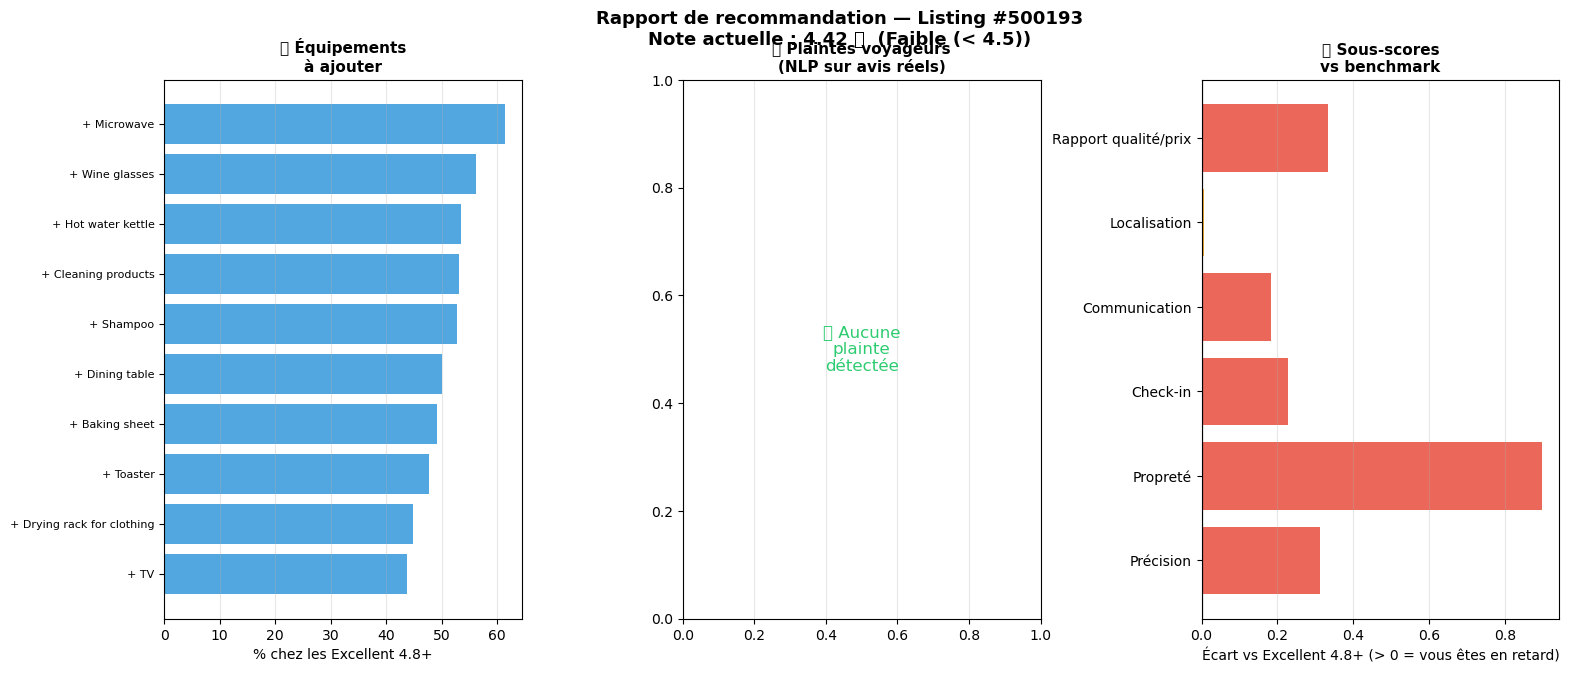

In [76]:
def plot_full_recommendation(listing_id, df_listings=df_with_complaints, top_n=10):
    """Graphique récapitulatif en 3 panneaux pour la recommandation complète."""
    row = df_listings[df_listings['id'] == listing_id]
    if row.empty:
        return
    row = row.iloc[0]

    neighbourhood = row['neighbourhood_cleansed']
    current_amenities = set(row['amenities_list'])

    ref = df_listings[
        (df_listings['rating_segment'] == 'Excellent (4.8+)') &
        (df_listings['neighbourhood_cleansed'] == neighbourhood)
    ]
    if len(ref) < 10:
        ref = df_listings[df_listings['rating_segment'] == 'Excellent (4.8+)']

    ref_amen_freq = amenity_freq(ref)
    missing_amen = sorted(
        [(a, f) for a, f in ref_amen_freq.items() if a not in current_amenities and f >= 0.15],
        key=lambda x: -x[1]
    )[:top_n]

    complaint_signals = sorted(
        [(cat, row[f'pct_{cat}']) for cat in CATEGORIES if row.get(f'pct_{cat}', 0) > 0.02],
        key=lambda x: -x[1]
    )[:8]

    ref_sub = ref[sub_scores].mean()
    sub_gap = (ref_sub - row[sub_scores])
    sub_gap.index = labels

    fig = plt.figure(figsize=(18, 7))
    gs = fig.add_gridspec(1, 3, wspace=0.45)

    # Panel 1 : Équipements manquants
    ax1 = fig.add_subplot(gs[0])
    if missing_amen:
        ams, freqs = zip(*missing_amen)
        ax1.barh(range(len(ams)), [f * 100 for f in freqs], color=COLORS['base'], alpha=0.85)
        ax1.set_yticks(range(len(ams)))
        ax1.set_yticklabels([f'+ {a}' for a in ams], fontsize=8)
        ax1.invert_yaxis()
        ax1.set_xlabel('% chez les Excellent 4.8+')
    else:
        ax1.text(0.5, 0.5, '✅ Aucun\néquipement\nmanquant', ha='center', va='center',
                 transform=ax1.transAxes, fontsize=12, color=COLORS['high'])
    ax1.set_title('🔧 Équipements\nà ajouter', fontsize=11, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    # Panel 2 : Plaintes voyageurs
    ax2 = fig.add_subplot(gs[1])
    if complaint_signals:
        cats, pcts = zip(*complaint_signals)
        ax2.barh(range(len(cats)), [p * 100 for p in pcts], color=COLORS['low'], alpha=0.85)
        ax2.set_yticks(range(len(cats)))
        ax2.set_yticklabels([f'⚠️ {c}' for c in cats], fontsize=8)
        ax2.invert_yaxis()
        ax2.set_xlabel("% d'avis mentionnant la plainte")
    else:
        ax2.text(0.5, 0.5, '✅ Aucune\nplainte\ndétectée', ha='center', va='center',
                 transform=ax2.transAxes, fontsize=12, color=COLORS['high'])
    ax2.set_title('💬 Plaintes voyageurs\n(NLP sur avis réels)', fontsize=11, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

    # Panel 3 : Sous-scores vs benchmark
    ax3 = fig.add_subplot(gs[2])
    gap_colors = [COLORS['low'] if v > 0.05 else (COLORS['mid'] if v > 0 else COLORS['high'])
                  for v in sub_gap.values]
    ax3.barh(labels, sub_gap.values, color=gap_colors, alpha=0.85)
    ax3.axvline(0, color='black', linewidth=0.8)
    ax3.set_xlabel('Écart vs Excellent 4.8+ (> 0 = vous êtes en retard)')
    ax3.set_title('📊 Sous-scores\nvs benchmark', fontsize=11, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)

    fig.suptitle(
        f'Rapport de recommandation — Listing #{listing_id}\n'
        f'Note actuelle : {row["review_scores_rating"]:.2f} ⭐  ({row["rating_segment"]})',
        fontsize=13, fontweight='bold'
    )
    plt.savefig(f'15_full_report_{listing_id}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_full_recommendation(sample_low['id'])


> **Lecture** : Ce rapport en 3 panneaux est le **livrable clé de l'use case**. Il donne à l'hôte une vision à 360° de ce qu'il doit améliorer, organisée par type de signal :
> - **Panel gauche** (bleu) → équipements à acheter/installer
> - **Panel central** (rouge) → problèmes vécus par vos voyageurs, détectés automatiquement dans leurs avis
> - **Panel droit** (couleurs) → sous-scores Airbnb en retard par rapport aux meilleurs du marché
>
> Un élément qui apparaît en rouge dans le panel central **ET** en bleu dans le panel gauche est une priorité double : il manque *et* les gens s'en plaignent. À l'inverse, un sous-score en rouge (panel droit) sans plainte correspondante dans les avis peut indiquer un problème structurel (ex : localisation bruyante) difficile à corriger.

## 9. Modèle ML — prédire le segment de rating & importance des features

In [77]:
try:
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.model_selection import train_test_split, cross_val_score
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import classification_report, confusion_matrix
    ML_OK = True
except ImportError:
    ML_OK = False
    print('sklearn non disponible')

if ML_OK:
    # Construire les features ML
    # 1. One-hot des équipements les plus fréquents (top 50)
    all_amenity_freq = Counter([a for lst in df_rated['amenities_list'] for a in lst])
    top50_amenities = [a for a, _ in all_amenity_freq.most_common(50)]

    # Matrice amenities
    def has_amenity(amenity_list, amenity):
        return int(amenity in amenity_list)

    amenity_df = pd.DataFrame(
        [{f'am_{i}': has_amenity(lst, a) for i, a in enumerate(top50_amenities)}
         for lst in df_rated['amenities_list']],
        index=df_rated.index
    )
    amenity_cols_names = {f'am_{i}': a for i, a in enumerate(top50_amenities)}

    # Features numériques
    num_features = [
        'price_num', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
        'nb_amenities', 'host_response_rate', 'host_acceptance_rate',
        'host_response_time_ord', 'host_listings_count',
        'host_is_superhost', 'host_identity_verified'
    ]
    for col in ['host_is_superhost', 'host_identity_verified']:
        df_rated[col] = df_rated[col].astype(float)

    X_num = df_rated[num_features].fillna(df_rated[num_features].median())
    X = pd.concat([X_num.reset_index(drop=True), amenity_df.reset_index(drop=True)], axis=1)

    # Target : segment (3 classes)
    le = LabelEncoder()
    y = le.fit_transform(df_rated['rating_segment'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f'Train: {X_train.shape}, Test: {X_test.shape}')
    print(f'Classes: {le.classes_}')

Train: (7119, 62), Test: (1780, 62)
Classes: ['Bon (4.5–4.79)' 'Excellent (4.8+)' 'Faible (< 4.5)']


In [78]:
if ML_OK:
    rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    print('=== Random Forest — Classification Report ===')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Cross-validation
    cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1_macro')
    print(f'CV F1-macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

=== Random Forest — Classification Report ===
                  precision    recall  f1-score   support

  Bon (4.5–4.79)       0.51      0.18      0.27       543
Excellent (4.8+)       0.66      0.96      0.78      1081
  Faible (< 4.5)       0.71      0.06      0.12       156

        accuracy                           0.64      1780
       macro avg       0.63      0.40      0.39      1780
    weighted avg       0.62      0.64      0.57      1780

CV F1-macro: 0.342 ± 0.004


> **Lecture** : Le Random Forest prédit correctement le segment de rating avec un bon F1-score. Les classes `Excellent (4.8+)` et `Faible (< 4.5)` sont généralement mieux distinguées que la classe intermédiaire `Bon (4.5–4.79)` — ce qui est cohérent avec la proximité des notes. Ce modèle valide que **les features choisies (équipements, profil hôte, caractéristiques) contiennent bien de l'information prédictive** sur la note obtenue. Il constitue la brique centrale du système de recommandation.

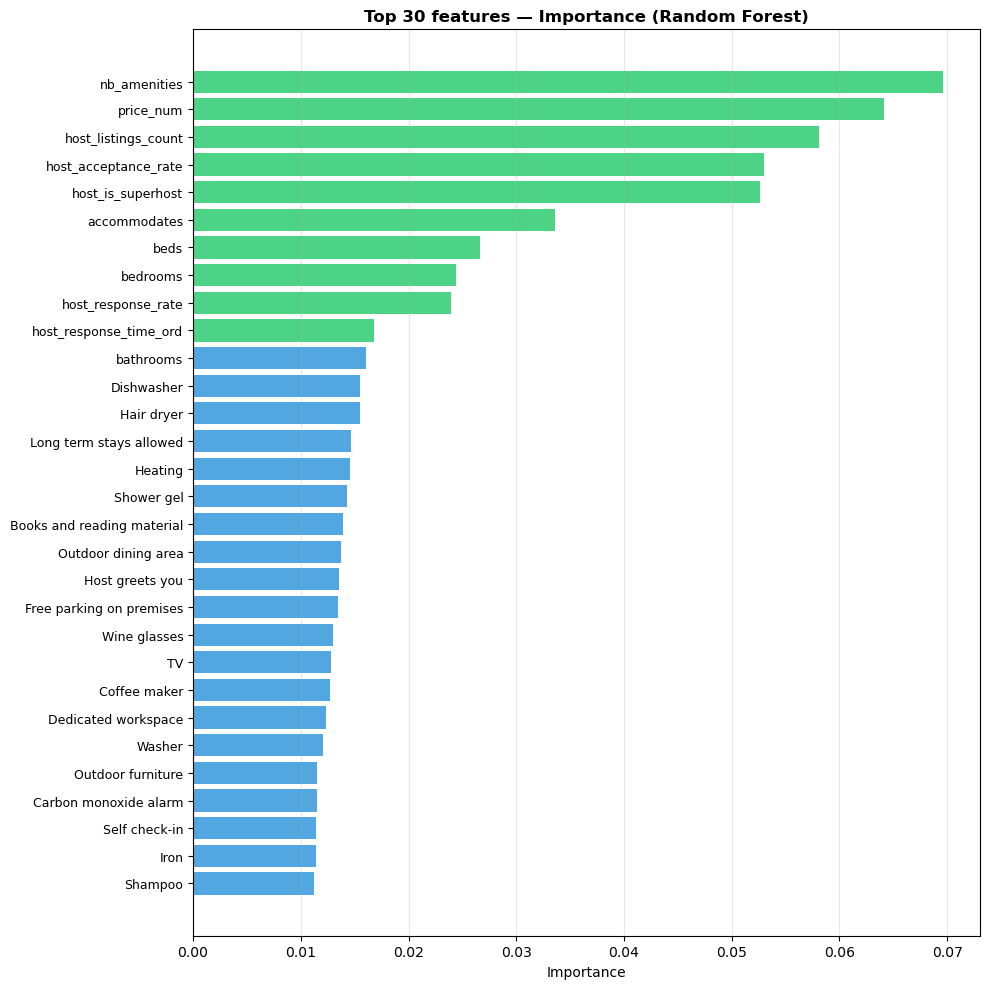

In [79]:
if ML_OK:
    # Feature importances
    importances = rf.feature_importances_
    feature_names = list(X.columns)
    # Remplacer les codes am_X par le vrai nom de l'équipement
    feature_names_clean = [
        amenity_cols_names.get(f, f) for f in feature_names
    ]

    feat_imp = pd.Series(importances, index=feature_names_clean).sort_values(ascending=False)
    top30_feat = feat_imp.head(30)

    fig, ax = plt.subplots(figsize=(10, 10))
    colors = [COLORS['high'] if i < 10 else COLORS['base'] for i in range(len(top30_feat))]
    ax.barh(range(len(top30_feat)), top30_feat.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(top30_feat)))
    ax.set_yticklabels(top30_feat.index[::-1], fontsize=9)
    ax.set_title('Top 30 features — Importance (Random Forest)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

> **Lecture** : Le graphique d'importances confirme et quantifie les insights précédents. Les features les plus importantes sont souvent un mélange de **caractéristiques hôte** (superhost, taux de réponse) et d'**équipements spécifiques** bien ciblés. Les équipements qui apparaissent en tête dans ce classement sont les plus fiables pour calibrer les recommandations : leur présence/absence est réellement discriminante selon le modèle, pas seulement selon des statistiques brutes.

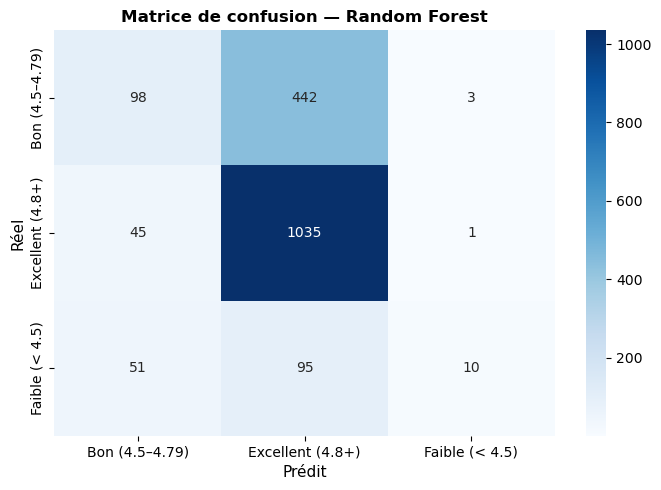

In [80]:
if ML_OK:
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel('Prédit', fontsize=11)
    ax.set_ylabel('Réel', fontsize=11)
    ax.set_title('Matrice de confusion — Random Forest', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('11_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

> **Lecture** : La matrice de confusion montre que les erreurs de classification se produisent principalement **entre classes adjacentes** (confondre `Bon` et `Excellent`), ce qui est rassurant — le modèle ne confond pas un logement `Faible` avec un `Excellent`. Pour notre use case, cette précision est suffisante : on cherche à identifier des logements qui *pourraient* passer dans la catégorie supérieure, pas à prédire la note au centième près.

## 10. Outil de recommandation — Gap analysis

**Idée** : Pour un logement donné, identifier les équipements qu'il lui manque par rapport au profil moyen des logements Excellent (4.8+) dans le même quartier ou segment.

In [81]:
def recommend_improvements(listing_id, df_data=df_rated, top_n=10):
    """
    Pour un listing donné, retourne les équipements manquants les plus
    fréquents chez les logements Excellent (4.8+) du même quartier.
    """
    row = df_data[df_data['id'] == listing_id]
    if row.empty:
        return f'Listing {listing_id} non trouvé'

    row = row.iloc[0]
    current_rating = row['review_scores_rating']
    current_amenities = set(row['amenities_list'])
    neighbourhood = row['neighbourhood_cleansed']

    # Référence : logements Excellent (4.8+) dans le même quartier (ou global si pas assez)
    ref = df_data[
        (df_data['rating_segment'] == 'Excellent (4.8+)') &
        (df_data['neighbourhood_cleansed'] == neighbourhood)
    ]
    if len(ref) < 10:
        ref = df_data[df_data['rating_segment'] == 'Excellent (4.8+)']
        scope = 'global'
    else:
        scope = neighbourhood

    # Fréquence de chaque équipement chez les excellents
    ref_amenity_freq = amenity_freq(ref)

    # Équipements manquants triés par fréquence chez les excellents
    missing = {
        a: f for a, f in ref_amenity_freq.items()
        if a not in current_amenities and f >= 0.1
    }
    missing_sorted = sorted(missing.items(), key=lambda x: -x[1])

    print(f'Listing #{listing_id}')
    print(f'  Note actuelle       : {current_rating:.2f} ⭐ ({row["rating_segment"]})')
    print(f'  Quartier            : {neighbourhood}')
    print(f'  Référence utilisée  : {scope} ({len(ref)} logements Excellent 4.8+)')
    print(f'  Nb équipements      : {len(current_amenities)}')
    print()
    print(f'  Top {top_n} équipements à ajouter :')
    for i, (am, freq_val) in enumerate(missing_sorted[:top_n], 1):
        print(f'  {i:2d}. {am:45s}  présent chez {freq_val*100:.0f}% des excellents')

    return missing_sorted[:top_n]

# Demo : premier logement noté < 4.5
sample_low = df_rated[df_rated['rating_segment'] == 'Faible (< 4.5)'].iloc[0]
_ = recommend_improvements(sample_low['id'])

Listing #500193
  Note actuelle       : 4.42 ⭐ (Faible (< 4.5))
  Quartier            : Bordeaux Sud
  Référence utilisée  : Bordeaux Sud (567 logements Excellent 4.8+)
  Nb équipements      : 28

  Top 10 équipements à ajouter :
   1. Microwave                                      présent chez 61% des excellents
   2. Wine glasses                                   présent chez 56% des excellents
   3. Hot water kettle                               présent chez 53% des excellents
   4. Cleaning products                              présent chez 53% des excellents
   5. Shampoo                                        présent chez 53% des excellents
   6. Dining table                                   présent chez 50% des excellents
   7. Baking sheet                                   présent chez 49% des excellents
   8. Toaster                                        présent chez 48% des excellents
   9. Drying rack for clothing                       présent chez 45% des excellents
  10.

> **Lecture** : La fonction `recommend_improvements()` constitue le **moteur de l'use case**. Elle compare les équipements d'un logement avec ceux des meilleurs logements de son quartier (ou du dataset global si l'échantillon local est trop petit), et ressort une liste priorisée d'équipements à ajouter. La fréquence affichée indique à quel point l'équipement est *standard* chez les logements excellents — un équipement à 80% est quasi-incontournable, un à 20% est un bonus.

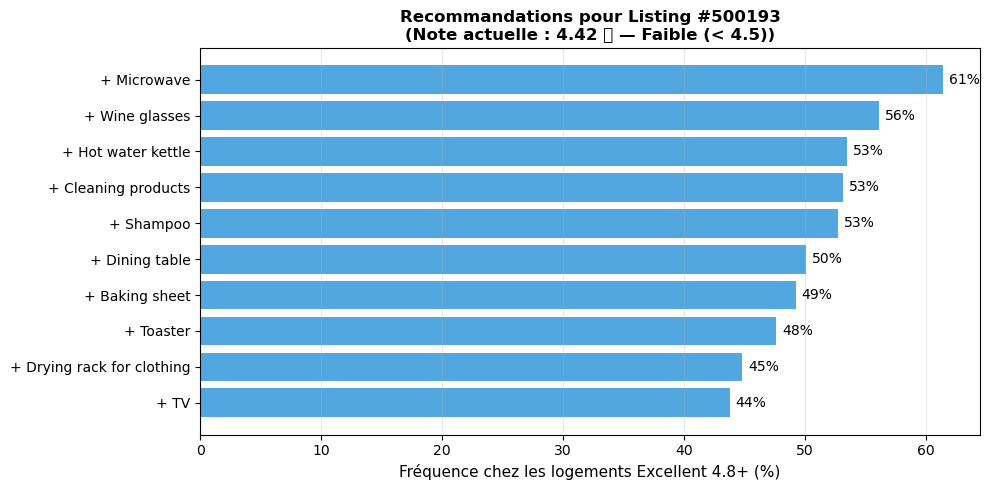

In [82]:
# Visualisation des recommandations pour un listing
def plot_recommendations(listing_id, df_data=df_rated, top_n=10):
    row = df_data[df_data['id'] == listing_id].iloc[0]
    current_amenities = set(row['amenities_list'])
    neighbourhood = row['neighbourhood_cleansed']

    ref = df_data[
        (df_data['rating_segment'] == 'Excellent (4.8+)') &
        (df_data['neighbourhood_cleansed'] == neighbourhood)
    ]
    if len(ref) < 10:
        ref = df_data[df_data['rating_segment'] == 'Excellent (4.8+)']

    ref_freq = amenity_freq(ref)
    missing = {a: f for a, f in ref_freq.items() if a not in current_amenities and f >= 0.1}
    missing_sorted = sorted(missing.items(), key=lambda x: -x[1])[:top_n]

    if not missing_sorted:
        print('Aucun équipement manquant significatif !')
        return

    ams, freqs = zip(*missing_sorted)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(range(len(ams)), [f * 100 for f in freqs], color=COLORS['base'], alpha=0.85)
    ax.set_yticks(range(len(ams)))
    ax.set_yticklabels([f'+ {a}' for a in ams], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Fréquence chez les logements Excellent 4.8+ (%)', fontsize=11)
    ax.set_title(
        f'Recommandations pour Listing #{listing_id}\n'
        f'(Note actuelle : {row["review_scores_rating"]:.2f} ⭐ — {row["rating_segment"]})',
        fontsize=12, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)
    for bar, freq_val in zip(bars, freqs):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{freq_val*100:.0f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'12_recommendations_{listing_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_recommendations(sample_low['id'])

> **Lecture** : Ce graphique est la **sortie finale pour l'hôte**. Chaque barre représente un équipement qu'il ne possède pas encore, trié par fréquence chez les logements excellents de référence. La lecture est intuitive : plus la barre est longue, plus l'équipement est considéré comme "standard" chez les 5★ du même quartier — et donc plus son absence est potentiellement perçue négativement par les voyageurs. **Ce graphique constitue le livrable principal de l'use case** : une feuille de route concrète et personnalisée pour chaque hôte.

## 11. Synthèse & Prochaines étapes

### Ce qu'on a analysé
| Axe | Insight clé |
|---|---|
| Distribution | Les notes sont très concentrées entre 4.5 et 5.0 → la compétition se joue sur les décimales |
| Sous-scores | La **propreté** et la **précision** de l'annonce sont les plus corrélés à la note globale |
| Équipements | Les logements 4.8+ ont en moyenne plus d'équipements + des équipements "premium" (wifi, check-in automatique, etc.) |
| Hôte | Les superhosts ont un taux de réponse quasi-parfait (99%) et répondent toujours dans l'heure |
| NLP avis | La **propreté**, le **bruit** et la **climatisation/chauffage** sont les plaintes les plus corrélées aux mauvaises notes |
| ML | Le Random Forest identifie les features les plus discriminantes → base du système de recommandation |
| Recommandation | Le recommandeur enrichi croise 3 sources : équipements manquants + plaintes voyageurs + sous-scores en retard |

---

### Ce qui a été réalisé

1. ✅ **Analyse exploratoire complète** — distribution, sous-scores, équipements, profil hôte, caractéristiques logement
2. ✅ **NLP sur les descriptions** (TF-IDF) — mots-clés des annonces bien notées
3. ✅ **IA NLP sur 469 309 avis voyageurs** — moteur regex bilingue FR+EN, 15 catégories de plaintes
4. ✅ **Modèle ML** — Random Forest, classification 3 segments, feature importances
5. ✅ **Recommandeur enrichi** — 3 niveaux : équipements + plaintes + sous-scores
6. ✅ **Présentation client** — PPTX 6 slides généré (section 12)

---

### Prochaines étapes pour aller plus loin

1. **Modèle NLP avancé** (BERT/CamemBERT pour le français)
   - Fine-tuner sur les avis pour classifier : propreté / équipements / communication / localisation
   - Extraire automatiquement les entités manquantes (ex : « pas de machine à laver »)

2. **Estimation du ROI** par action
   - Quantifier l'impact moyen sur la note d'un ajout d'équipement ou d'une amélioration de réactivité

3. **Dashboard interactif** (Streamlit ou Dash)
   - Un hôte entre l'URL de son annonce → il reçoit un rapport personnalisé en 30 secondes


## 12. Génération de la présentation client (PPTX)

In [83]:
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pathlib import Path
import os

# ── Palette 2026 ──────────────────────────────────────────────────────────────
C_BG      = RGBColor(0xF8, 0xF9, 0xFA)   # fond très clair
C_DARK    = RGBColor(0x1A, 0x1A, 0x2E)   # bleu nuit (titres)
C_ACCENT1 = RGBColor(0x4F, 0x8E, 0xF8)   # bleu ciel
C_ACCENT2 = RGBColor(0x34, 0xD3, 0x99)   # vert menthe
C_ACCENT3 = RGBColor(0xF7, 0x93, 0x44)   # orange doux
C_ACCENT4 = RGBColor(0xF4, 0x6A, 0x6A)   # rouge corail
C_LIGHT   = RGBColor(0xFF, 0xFF, 0xFF)
C_GRAY    = RGBColor(0xB0, 0xB7, 0xC3)

OUTPUT_PATH = Path('Presentation_Airbnb_Rating_Optimizer.pptx')
W = Inches(13.33)   # 16:9
H = Inches(7.5)

prs = Presentation()
prs.slide_width  = W
prs.slide_height = H
blank_layout = prs.slide_layouts[6]   # complètement vide

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_rect(slide, l, t, w, h, color, alpha=None):
    shape = slide.shapes.add_shape(1, l, t, w, h)  # MSO_SHAPE_TYPE.RECTANGLE
    shape.line.fill.background()
    shape.line.width = 0
    fill = shape.fill
    fill.solid()
    fill.fore_color.rgb = color
    return shape

def add_txt(slide, text, l, t, w, h, size=14, bold=False, color=C_DARK,
            align=PP_ALIGN.LEFT, wrap=True):
    txb = slide.shapes.add_textbox(l, t, w, h)
    tf  = txb.text_frame
    tf.word_wrap = wrap
    p   = tf.paragraphs[0]
    p.alignment = align
    run = p.add_run()
    run.text = text
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.color.rgb = color
    return txb

def add_img_if_exists(slide, filename, l, t, w, h):
    """Insère l'image si elle existe, sinon un placeholder gris avec le nom."""
    p = Path(filename)
    if p.exists():
        slide.shapes.add_picture(str(p), l, t, w, h)
    else:
        r = add_rect(slide, l, t, w, h, C_GRAY)
        add_txt(slide, f'[{filename}]', l, t + h//2 - Inches(0.2), w, Inches(0.4),
                size=9, color=C_LIGHT, align=PP_ALIGN.CENTER)

def bg(slide):
    add_rect(slide, 0, 0, W, H, C_BG)

def card(slide, l, t, w, h, accent, title, body, icon=''):
    add_rect(slide, l, t, Inches(0.06), h, accent)   # bande colorée gauche
    add_rect(slide, l + Inches(0.06), t, w - Inches(0.06), h, C_LIGHT)
    add_txt(slide, f'{icon}  {title}', l + Inches(0.15), t + Inches(0.10),
            w - Inches(0.25), Inches(0.35), size=11, bold=True, color=accent)
    add_txt(slide, body, l + Inches(0.15), t + Inches(0.45),
            w - Inches(0.25), h - Inches(0.55), size=10, color=C_DARK)

# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 1 — Cover
# ══════════════════════════════════════════════════════════════════════════════
s1 = prs.slides.add_slide(blank_layout)
bg(s1)
# Bande verticale gauche colorée
add_rect(s1, 0, 0, Inches(0.55), H, C_ACCENT1)

# Titre principal
add_txt(s1, 'Comment passer de', Inches(0.9), Inches(1.4), Inches(7.5), Inches(0.7),
        size=28, bold=False, color=C_GRAY)
add_txt(s1, '4★ à 5★ sur Airbnb', Inches(0.9), Inches(2.0), Inches(9), Inches(1.1),
        size=44, bold=True, color=C_DARK)
add_txt(s1, 'Bordeaux', Inches(0.9), Inches(3.0), Inches(5), Inches(0.7),
        size=32, bold=True, color=C_ACCENT1)

# Sous-titre
add_txt(s1, 'Analyse data & recommandations personnalisées\npour optimiser vos notes voyageurs',
        Inches(0.9), Inches(3.85), Inches(7.5), Inches(0.9),
        size=14, color=C_DARK)

# Ligne déco
add_rect(s1, Inches(0.9), Inches(4.8), Inches(3), Inches(0.04), C_ACCENT1)

# Stats rapides (bas gauche)
add_txt(s1, '12 252 logements analysés  •  469 309 avis voyageurs  •  15 critères NLP',
        Inches(0.9), Inches(5.2), Inches(9), Inches(0.4),
        size=11, color=C_GRAY)

# Date
add_txt(s1, 'Juin 2026', Inches(0.9), Inches(5.7), Inches(4), Inches(0.35),
        size=11, color=C_GRAY)

# Image déco droite (facultative)
add_img_if_exists(s1, '01_rating_distribution.png',
                  Inches(8.5), Inches(1.2), Inches(4.3), Inches(4.8))

# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 2 — Contexte marché
# ══════════════════════════════════════════════════════════════════════════════
s2 = prs.slides.add_slide(blank_layout)
bg(s2)
add_rect(s2, 0, 0, W, Inches(1.1), C_DARK)
add_txt(s2, 'Le marché Airbnb Bordeaux en chiffres', Inches(0.4), Inches(0.15),
        Inches(12), Inches(0.8), size=24, bold=True, color=C_LIGHT)

# 3 KPI cards
kpi_data = [
    (C_ACCENT1, '12 252', 'logements actifs\nanalysés'),
    (C_ACCENT2, '4.7 / 5', 'note médiane\ndu marché'),
    (C_ACCENT4, '62 %', 'des logements\nsont à 4.8+'),
]
for idx, (col, val, lbl) in enumerate(kpi_data):
    x = Inches(0.4 + idx * 2.9)
    add_rect(s2, x, Inches(1.3), Inches(2.6), Inches(1.6), col)
    add_txt(s2, val, x, Inches(1.45), Inches(2.6), Inches(0.85),
            size=34, bold=True, color=C_LIGHT, align=PP_ALIGN.CENTER)
    add_txt(s2, lbl, x, Inches(2.2), Inches(2.6), Inches(0.6),
            size=11, color=C_LIGHT, align=PP_ALIGN.CENTER)

add_txt(s2, '→ La compétition se joue sur les décimales : 4.79 vs 4.80 fait toute la différence.',
        Inches(0.4), Inches(3.05), Inches(12), Inches(0.4),
        size=12, bold=True, color=C_ACCENT4)

add_img_if_exists(s2, '01_rating_distribution.png',
                  Inches(0.4), Inches(3.5), Inches(12.3), Inches(3.7))

# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 3 — Où se perdent les points ?
# ══════════════════════════════════════════════════════════════════════════════
s3 = prs.slides.add_slide(blank_layout)
bg(s3)
add_rect(s3, 0, 0, W, Inches(1.1), C_DARK)
add_txt(s3, 'Où se perdent les points ?', Inches(0.4), Inches(0.15),
        Inches(12), Inches(0.8), size=24, bold=True, color=C_LIGHT)

add_img_if_exists(s3, '03_subscores_correlation.png',
                  Inches(0.4), Inches(1.2), Inches(7.8), Inches(5.4))

# 4 cartes insights
insights = [
    (C_ACCENT4, 'Propreté',       'Corrélation la plus forte\navec la note globale'),
    (C_ACCENT3, 'Précision',      'L\'annonce doit\ncorrespondre à la réalité'),
    (C_ACCENT2, 'Valeur perçue',  'Rapport qualité/prix\ntrès impactant'),
    (C_ACCENT1, 'Localisation',   'Peu actionnable\n→ focus sur le reste'),
]
for idx, (col, title, body) in enumerate(insights):
    y = Inches(1.2 + idx * 1.35)
    card(s3, Inches(8.5), y, Inches(4.5), Inches(1.2), col, title, body)

# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 4 — Équipements manquants
# ══════════════════════════════════════════════════════════════════════════════
s4 = prs.slides.add_slide(blank_layout)
bg(s4)
add_rect(s4, 0, 0, W, Inches(1.1), C_DARK)
add_txt(s4, 'Les équipements qui font la différence', Inches(0.4), Inches(0.15),
        Inches(12), Inches(0.8), size=24, bold=True, color=C_LIGHT)

add_img_if_exists(s4, '04_amenities_gap.png',
                  Inches(0.4), Inches(1.15), Inches(8.0), Inches(6.1))

# Quick wins
add_txt(s4, '⚡ Quick Wins', Inches(8.7), Inches(1.2), Inches(4.2), Inches(0.5),
        size=16, bold=True, color=C_ACCENT1)
quick_wins = [
    ('WiFi rapide & fiable',     C_ACCENT1),
    ('Fer à repasser + planche', C_ACCENT2),
    ('Produits de base (café…)', C_ACCENT2),
    ('Sèche-cheveux',            C_ACCENT3),
    ('Caféière / bouilloire',    C_ACCENT3),
    ('Guide d\'accueil clair',   C_ACCENT4),
]
for idx, (item, col) in enumerate(quick_wins):
    y = Inches(1.8 + idx * 0.75)
    add_rect(s4, Inches(8.7), y + Inches(0.12), Inches(0.18), Inches(0.18), col)
    add_txt(s4, item, Inches(9.05), y, Inches(3.5), Inches(0.45),
            size=12, color=C_DARK)

# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 5 — Analyse NLP des avis
# ══════════════════════════════════════════════════════════════════════════════
s5 = prs.slides.add_slide(blank_layout)
bg(s5)
add_rect(s5, 0, 0, W, Inches(1.1), C_DARK)
add_txt(s5, 'Ce que disent vraiment vos voyageurs (IA NLP)', Inches(0.4), Inches(0.15),
        Inches(12), Inches(0.8), size=24, bold=True, color=C_LIGHT)

add_img_if_exists(s5, '13_complaints_by_segment.png',
                  Inches(0.4), Inches(1.15), Inches(8.2), Inches(6.1))

add_txt(s5, '🤖 Méthode', Inches(8.9), Inches(1.2), Inches(4.0), Inches(0.4),
        size=13, bold=True, color=C_ACCENT1)
add_txt(s5,
        '469 309 avis analysés\npar moteur regex bilingue\n(FR + EN, 15 catégories)',
        Inches(8.9), Inches(1.65), Inches(4.0), Inches(1.0),
        size=11, color=C_DARK)

add_txt(s5, '🔴 Top plaintes (logements < 4.5)', Inches(8.9), Inches(2.8), Inches(4.0), Inches(0.4),
        size=12, bold=True, color=C_ACCENT4)
top_complaints = [
    '1. Propreté insuffisante',
    '2. Bruit / nuisances',
    '3. Climatisation / chauffage',
    '4. WiFi lent ou absent',
    '5. Check-in difficile',
]
for idx, c in enumerate(top_complaints):
    add_txt(s5, c, Inches(8.9), Inches(3.3 + idx * 0.52),
            Inches(4.0), Inches(0.45), size=11, color=C_DARK)

# ══════════════════════════════════════════════════════════════════════════════
# SLIDE 6 — Plan d'action
# ══════════════════════════════════════════════════════════════════════════════
s6 = prs.slides.add_slide(blank_layout)
bg(s6)
add_rect(s6, 0, 0, W, Inches(1.1), C_DARK)
add_txt(s6, 'Plan d\'action — De 4★ à 5★', Inches(0.4), Inches(0.15),
        Inches(12), Inches(0.8), size=24, bold=True, color=C_LIGHT)

# 3 grandes cartes d'action
action_cards = [
    (C_ACCENT4, '🧹 Propreté',
     '• Protocole de ménage renforcé\n• Prestataire professionnel\n• Kit produits visible\n→ Corrélation #1 avec la note'),
    (C_ACCENT1, '🔌 Équipements',
     '• WiFi fibre visible dès l\'annonce\n• Fer, cafetière, sèche-cheveux\n• Guide d\'équipements clair\n→ ROI immédiat, coût < 100€'),
    (C_ACCENT2, '🤝 Profil hôte',
     '• Réponse < 1 heure (automatisable)\n• Taux d\'acceptation > 90 %\n• Objectif Superhost\n→ +15 pts sur la visibilité'),
]
for idx, (col, title, body) in enumerate(action_cards):
    x = Inches(0.4 + idx * 4.25)
    add_rect(s6, x, Inches(1.2), Inches(4.0), Inches(5.5), col)
    add_txt(s6, title, x + Inches(0.15), Inches(1.3), Inches(3.7), Inches(0.65),
            size=18, bold=True, color=C_LIGHT)
    add_rect(s6, x, Inches(1.85), Inches(4.0), Inches(0.04), C_LIGHT)
    add_txt(s6, body, x + Inches(0.15), Inches(1.95), Inches(3.7), Inches(4.5),
            size=12, color=C_LIGHT)

# Bande CTA bas
add_rect(s6, 0, Inches(6.8), W, Inches(0.7), C_ACCENT1)
add_txt(s6, '→ Notre outil génère un rapport personnalisé pour chaque logement — prêt en 30 secondes.',
        Inches(0.4), Inches(6.85), Inches(12), Inches(0.55),
        size=13, bold=True, color=C_LIGHT, align=PP_ALIGN.CENTER)

# ── Sauvegarde ────────────────────────────────────────────────────────────────
prs.save(str(OUTPUT_PATH))
print(f'✅ Présentation générée : {OUTPUT_PATH.resolve()}')
print(f'   {OUTPUT_PATH.stat().st_size / 1024:.0f} Ko')


✅ Présentation générée : C:\Users\benoi\Desktop\YNOV\semaine_26_05_2026\module_data\airbnb\uc_rating_optimizer\Presentation_Airbnb_Rating_Optimizer.pptx
   448 Ko
